# Data collection

## Overview

The Space-Track Data Fetcher is a Python script that retrieves and merges data from two different endpoints of the Space-Track API: the SATCAT (Satellite Catalog) and the GP (General Perturbations) data.

## Key Components

### 1. Authentication

The script authenticates with the Space-Track API using credentials stored in environment variables, ensuring secure access to the API without hardcoding sensitive information.

### 2. Data Retrieval

Two main types of data are fetched:
- SATCAT data: Basic information about space objects
- GP data: More detailed orbital information

The script uses HTTP requests to fetch this data from the respective API endpoints.

### 3. Data Merging

After retrieving both SATCAT and GP data, the script merges them based on the NORAD Catalog ID (NORAD_CAT_ID). This creates a comprehensive dataset where each SATCAT entry is enriched with its corresponding GP data.

### 4. Incremental Updates

The script can perform incremental updates by:
- Checking for existing data files
- Determining the highest NORAD_CAT_ID in the existing data
- Fetching only new data (with NORAD_CAT_IDs higher than the maximum in the existing data)

This functionality allows for efficient updating of large datasets without re-downloading existing data.

### 5. Data Storage

The merged data is stored in a JSONL (JSON Lines) format, where each line represents a single space object with its combined SATCAT and GP data.

## Workflow

1. **Setup**: The script sets up logging and loads necessary environment variables.

2. **Authentication**: It logs in to the Space-Track API and obtains session cookies.

3. **Endpoint Determination**: Based on whether an existing data file is provided, the script determines the appropriate API endpoints to use (either for full data retrieval or incremental update).

4. **Data Fetching**: The script fetches data from both the SATCAT and GP endpoints.

5. **Data Merging**: The fetched data is merged, combining SATCAT and GP information for each space object.

6. **Data Storage**: The merged data is either appended to an existing file (in the case of an incremental update) or written to a new file.

## Use Cases

The script can be used for:
- Creating comprehensive datasets for analysis of space objects and their orbits

## Extensibility

The modular nature of the script allows for potential extensions, such as:
- Adding more data sources from other Space-Track API endpoints
- Implementing additional data processing or filtering logic
- Integrating with other data analysis or visualization tools

## Conclusion

The Space-Track Data Fetcher provides a method for retrieving, merging, and storing space object data from the Space-Track API. It can handle both full data retrieval and incremental updates for space data management and analysis.

## Code

In [ ]:
!pip install -q python-dotenv

In [ ]:
from google.colab import files
import getpass
import os

def prepare_env_file():
  # Prompt for username and password
  username = input("Enter your Space-Track username: ")
  password = getpass.getpass("Enter your Space-Track password: ")

  # Create .env file content
  env_content = f"ST_IDENTITY={username}\nST_PASSWORD={password}\n"

  # Write to .env file
  with open('.env', 'w') as f:
      f.write(env_content)

  print(".env file created successfully.")

  # Verify the file was created (without displaying its contents)
  print("Contents of current directory:")
  !ls -la

  print("\nYour credentials have been saved to the .env file.")
  print("The data fetching script will use these credentials to authenticate with Space-Track.")

In [ ]:
import http.client
import json
from urllib.parse import urlencode
from dotenv import load_dotenv
import os
import sys
import logging

# Load environment variables from .env file
load_dotenv()

# Configure logging
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)


def login():
    """
    Log in to Space-Track API and return the session cookies.
    """
    logging.info("Logging in to Space-Track")
    conn = http.client.HTTPSConnection("www.space-track.org")
    payload = urlencode(
        {"identity": os.getenv("ST_IDENTITY"), "password": os.getenv("ST_PASSWORD")}
    )
    headers = {
        "Content-Type": "application/x-www-form-urlencoded",
    }
    conn.request("POST", "/ajaxauth/login", payload, headers)
    res = conn.getresponse()
    cookies = res.getheader("Set-Cookie")
    conn.close()
    logging.info("Login successful")
    return cookies


def fetch_data(cookies, endpoint):
    """
    Fetch data from a given Space-Track API endpoint using the provided session cookies.
    """
    logging.info(f"Fetching data from endpoint: {endpoint}")
    conn = http.client.HTTPSConnection("www.space-track.org")
    headers = {
        "cookie": cookies,
    }
    conn.request("GET", endpoint, headers=headers)
    res = conn.getresponse()
    data = res.read()
    conn.close()
    logging.info("Data fetched successfully")
    return json.loads(data)


def merge_data(satcat_data, gp_data):
    """
    Merge SATCAT and GP data based on NORAD_CAT_ID.
    """
    logging.info("Merging data")
    gp_dict = {item["NORAD_CAT_ID"]: item for item in gp_data}
    for satcat_item in satcat_data:
        norad_id = satcat_item.get("NORAD_CAT_ID")
        satcat_item["OMM"] = gp_dict.get(norad_id, None)
    logging.info("Data merged successfully")
    return satcat_data


def get_max_norad_cat_id(file_path):
    """
    Get the maximum NORAD_CAT_ID from an existing data file.
    """
    logging.info(f"Checking existing data file: {file_path}")
    if not os.path.exists(file_path):
        logging.info("No existing data file found")
        return 0

    with open(file_path, "r") as file:
        max_id = 0
        for line in file:
            data = json.loads(line)
            norad_id = data.get("NORAD_CAT_ID", 0)
            if norad_id > max_id:
                max_id = norad_id
    logging.info(f"Max NORAD_CAT_ID found: {max_id}")
    return max_id


def det_space_track_data():
    # Get the existing data file path from command-line argument, if provided
    existing_data_file = sys.argv[1] if len(sys.argv) > 1 else None

    # Log in to Space-Track API
    cookies = login()

    # Determine the appropriate endpoints based on existing data
    if existing_data_file and os.path.exists(existing_data_file):
        max_norad_cat_id = get_max_norad_cat_id(existing_data_file)
        satcat_endpoint = f"/basicspacedata/query/class/satcat/NORAD_CAT_ID/%3E{max_norad_cat_id}/orderby/NORAD_CAT_ID%20asc/emptyresult/show"
        gp_endpoint = f"/basicspacedata/query/class/gp/NORAD_CAT_ID/%3E{max_norad_cat_id}/orderby/NORAD_CAT_ID%20asc/emptyresult/show"
        logging.info(
            f"Fetching incremental data with NORAD_CAT_ID > {max_norad_cat_id}"
        )
    else:
        # Fetch all data if no existing file or the file doesn't exist
        satcat_endpoint = "/basicspacedata/query/class/satcat/orderby/NORAD_CAT_ID%20asc/emptyresult/show"
        gp_endpoint = (
            "/basicspacedata/query/class/gp/orderby/NORAD_CAT_ID%20asc/emptyresult/show"
        )
        logging.info("Fetching all data")

    # Fetch SATCAT and GP data
    satcat_data = fetch_data(cookies, satcat_endpoint)
    gp_data = fetch_data(cookies, gp_endpoint)

    # Merge SATCAT and GP data
    merged_data = merge_data(satcat_data, gp_data)

    # Save or append the merged data
    if existing_data_file:
        with open(existing_data_file, "a") as file:
            for line in merged_data:
                file.write(json.dumps(line) + "\n")
        logging.info(f"Appended merged data to {existing_data_file}")
    else:
        with open("merged_result.jsonl", "w") as file:
            for line in merged_data:
                file.write(json.dumps(line) + "\n")
        logging.info("Saved merged data to merged_result.jsonl")


# Preprocessing

## Load data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
file_path = '/content/drive/MyDrive/data_with_RCS_value.jsonl'
excel_file_path = '/content/drive/MyDrive/UCS-Satellite-Database 5-1-2023.xlsx'

In [ ]:
file_path = '/content/data_with_RCS_value.jsonl'
excel_file_path = '/content/UCS-Satellite-Database 5-1-2023.xlsx'

In [ ]:
data = pd.read_json(file_path, lines=True)
data.head()
mass_data = pd.read_excel(excel_file_path)


In [ ]:
data.columns

Index(['INTLDES', 'NORAD_CAT_ID', 'OBJECT_TYPE', 'SATNAME', 'COUNTRY',
       'LAUNCH', 'SITE', 'DECAY', 'PERIOD', 'INCLINATION', 'APOGEE', 'PERIGEE',
       'COMMENT', 'COMMENTCODE', 'RCSVALUE', 'RCS_SIZE', 'FILE', 'LAUNCH_YEAR',
       'LAUNCH_NUM', 'LAUNCH_PIECE', 'CURRENT', 'OBJECT_NAME', 'OBJECT_ID',
       'OBJECT_NUMBER', 'OMM', 'RCS_VALUE'],
      dtype='object')

In [ ]:
data[["RCS_SIZE"]]

,RCS_SIZE
0,LARGE
1,None
2,SMALL
3,None
4,SMALL
...,...
60793,SMALL
60794,SMALL
60795,SMALL
60796,SMALL


In [ ]:
mass_data = mass_data[["NORAD Number","Dry Mass (kg.)", "Launch Mass (kg.)"]]
mass_data.columns = ["NORAD_CAT_ID", "dry_mass", "launch_mass"]
mass_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   NORAD_CAT_ID  7560 non-null   int64  
 1   dry_mass      767 non-null    object 
 2   launch_mass   7315 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 177.3+ KB


# RCS Check

In [ ]:
# Count how many results have an RCS Value
rcs_value_count = data['RCS_VALUE'].notna().sum()

# Count how many results with RCS Value also have a DECAY value
rcs_and_decay_count = data[(data['RCS_VALUE'].notna()) & (data['DECAY'].notna())].shape[0]

print(f"Number of results with RCS Value: {rcs_value_count}")
print(f"Number of results with both RCS Value and DECAY value: {rcs_and_decay_count}")

Number of results with RCS Value: 12063
Number of results with both RCS Value and DECAY value: 0


# Dry mass check

In [ ]:
# Count how many non-null dry_mass values are there
non_null_dry_mass_count = mass_data['dry_mass'].notna().sum()

# Count how many non-null launch_mass values are there
non_null_launch_mass_count = mass_data['launch_mass'].notna().sum()

# Merge the dataframes on NORAD_CAT_ID
merged_data = data.merge(mass_data, on='NORAD_CAT_ID', how='left')

# Count how many results have both non-null RCS_VALUE and dry_mass
rcs_and_dry_mass_count = merged_data[(merged_data['RCS_VALUE'].notna()) & (merged_data['dry_mass'].notna())].shape[0]

# Count how many results have both non-null RCS_VALUE and launch_mass
rcs_and_launch_mass_count = merged_data[(merged_data['RCS_VALUE'].notna()) & (merged_data['launch_mass'].notna())].shape[0]

# Count how many results have all three: non-null RCS_VALUE, dry_mass, and launch_mass
rcs_dry_and_launch_mass_count = merged_data[(merged_data['RCS_VALUE'].notna()) &
                                            (merged_data['dry_mass'].notna()) &
                                            (merged_data['launch_mass'].notna())].shape[0]

print(f"Number of non-null dry_mass values: {non_null_dry_mass_count}")
print(f"Number of non-null launch_mass values: {non_null_launch_mass_count}")
print(f"Number of results with both non-null RCS_VALUE and dry_mass: {rcs_and_dry_mass_count}")
print(f"Number of results with both non-null RCS_VALUE and launch_mass: {rcs_and_launch_mass_count}")
print(f"Number of results with non-null RCS_VALUE, dry_mass, and launch_mass: {rcs_dry_and_launch_mass_count}")

Number of non-null dry_mass values: 767
Number of non-null launch_mass values: 7315
Number of results with both non-null RCS_VALUE and dry_mass: 212
Number of results with both non-null RCS_VALUE and launch_mass: 532
Number of results with non-null RCS_VALUE, dry_mass, and launch_mass: 207


In [ ]:
import random
# Count how many results have all three: non-null RCS_VALUE, dry_mass, and launch_mass
check = merged_data[(merged_data['RCS_VALUE'].isna()) &
                                            (merged_data['RCS_SIZE'].notna())].shape[0]
norad_ids_with_rcs_value = data[(merged_data['RCS_VALUE'].isna()) &
                                            (merged_data['RCS_SIZE'].notna())]['NORAD_CAT_ID'].tolist()
sample_size = min(10, len(norad_ids_with_rcs_value))
random_norad_ids = random.sample(norad_ids_with_rcs_value, sample_size)

print("\nRandom sample of 10 NORAD_CAT_ID values with RCS_VALUE:")
for id in random_norad_ids:
    print(id)


Random sample of 10 NORAD_CAT_ID values with RCS_VALUE:
56728
54146
27170
53394
18450
51080
54550
48801
34698
21758


In [ ]:
import random
# Get a list of NORAD_CAT_ID values where RCS_VALUE is present
norad_ids_with_rcs = data[data['RCS_VALUE'].notna()]['NORAD_CAT_ID'].tolist()

# Randomly sample 10 NORAD_CAT_ID values (or all if less than 10)
sample_size = min(10, len(norad_ids_with_rcs))
random_norad_ids = random.sample(norad_ids_with_rcs, sample_size)

print("\nRandom sample of 10 NORAD_CAT_ID values with RCS_VALUE:")
for id in random_norad_ids:
    print(id)


Random sample of 10 NORAD_CAT_ID values with RCS_VALUE:
34382
12149
39122
29643
37691
15521
37363
30883
18122
34123


From the above analysis, it is safe to conclude that the number data points which contain both RCS and dry mass, are substantially lower than the amount needed to train a machine learning model.

## Basic cleanup and apply normalization on OMM column

In [ ]:
# Convert all column names in the DataFrame to uppercase
data.columns = data.columns.str.upper()

# Normalize 'omm_data' into separate columns if it exists
if 'OMM' in data.columns:
    omm_data_normalized = pd.json_normalize(data['OMM'])

    # Convert omm_data_normalized columns to uppercase and remove everything before the last dot
    omm_data_normalized.columns = omm_data_normalized.columns.str.upper().str.split('.').str[-1]

    # Only keep new columns that do not exist in the main DataFrame
    new_columns = omm_data_normalized.loc[:, ~omm_data_normalized.columns.isin(data.columns)]

    # Merge the new columns into the main DataFrame
    data = pd.concat([data.drop(columns=['OMM']), new_columns], axis=1)

data.drop(columns=['NORAD_CAT_ID'], inplace=True)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60798 entries, 0 to 60797
Data columns (total 54 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   INTLDES              60798 non-null  object 
 1   OBJECT_TYPE          60798 non-null  object 
 2   SATNAME              60798 non-null  object 
 3   COUNTRY              60798 non-null  object 
 4   LAUNCH               60798 non-null  object 
 5   SITE                 60798 non-null  object 
 6   DECAY                31499 non-null  object 
 7   PERIOD               59835 non-null  float64
 8   INCLINATION          59835 non-null  float64
 9   APOGEE               59835 non-null  float64
 10  PERIGEE              59835 non-null  float64
 11  COMMENT              935 non-null    object 
 12  COMMENTCODE          3558 non-null   float64
 13  RCSVALUE             60798 non-null  int64  
 14  RCS_SIZE             50540 non-null  object 
 15  FILE                 60798 non-null 

In [ ]:
# Remove rows will null DECAY dates
data.dropna(subset = ['DECAY'], inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31499 entries, 0 to 60639
Data columns (total 54 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   INTLDES              31499 non-null  object 
 1   OBJECT_TYPE          31499 non-null  object 
 2   SATNAME              31499 non-null  object 
 3   COUNTRY              31499 non-null  object 
 4   LAUNCH               31499 non-null  object 
 5   SITE                 31499 non-null  object 
 6   DECAY                31499 non-null  object 
 7   PERIOD               31176 non-null  float64
 8   INCLINATION          31176 non-null  float64
 9   APOGEE               31176 non-null  float64
 10  PERIGEE              31176 non-null  float64
 11  COMMENT              309 non-null    object 
 12  COMMENTCODE          1151 non-null   float64
 13  RCSVALUE             31499 non-null  int64  
 14  RCS_SIZE             22605 non-null  object 
 15  FILE                 31499 non-null  int6

In [ ]:
len(data['INTLDES'].unique())

31498

In [ ]:
data.drop(columns=['INTLDES', 'DECAY_DATE'], inplace=True)
data.head()

,OBJECT_TYPE,SATNAME,COUNTRY,LAUNCH,SITE,DECAY,PERIOD,INCLINATION,APOGEE,PERIGEE,...,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,APOAPSIS,PERIAPSIS,COUNTRY_CODE,LAUNCH_DATE,GP_ID,TLE_LINE0,TLE_LINE1,TLE_LINE2
0,ROCKET BODY,SL-1 R/B,CIS,1957-10-04,TTMTR,1957-12-01,96.19,65.10,938.0,214.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PAYLOAD,SPUTNIK 1,CIS,1957-10-04,TTMTR,1958-01-03,96.10,65.00,1080.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PAYLOAD,SPUTNIK 2,CIS,1957-11-03,TTMTR,1958-04-14,103.74,65.33,1659.0,211.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PAYLOAD,EXPLORER 1,US,1958-02-01,AFETR,1970-03-31,88.48,33.15,215.0,183.0,...,0.0000000000000,6577.283,215.419,182.876,None,None,8837957,0 EXPLORER 1,1 00004U 58001 A 70090.03500497 .07718844 +0...,2 00004 033.1468 334.6171 0024739 311.5310 048...
5,PAYLOAD,EXPLORER 3,US,1958-03-26,AFETR,1958-06-28,103.60,33.50,1739.0,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Convert LAUNCH and DECAY columns to datetime
data['LAUNCH'] = pd.to_datetime(data['LAUNCH'], format='%Y-%m-%d')
data['DECAY'] = pd.to_datetime(data['DECAY'], format='%Y-%m-%d')

# Calculate the lifetime in days
data['LIFETIME_DAYS'] = (data['DECAY'] - data['LAUNCH']).dt.days
data.head()

,OBJECT_TYPE,SATNAME,COUNTRY,LAUNCH,SITE,DECAY,PERIOD,INCLINATION,APOGEE,PERIGEE,...,SEMIMAJOR_AXIS,APOAPSIS,PERIAPSIS,COUNTRY_CODE,LAUNCH_DATE,GP_ID,TLE_LINE0,TLE_LINE1,TLE_LINE2,LIFETIME_DAYS
0,ROCKET BODY,SL-1 R/B,CIS,1957-10-04,TTMTR,1957-12-01,96.19,65.10,938.0,214.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58
1,PAYLOAD,SPUTNIK 1,CIS,1957-10-04,TTMTR,1958-01-03,96.10,65.00,1080.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91
2,PAYLOAD,SPUTNIK 2,CIS,1957-11-03,TTMTR,1958-04-14,103.74,65.33,1659.0,211.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162
3,PAYLOAD,EXPLORER 1,US,1958-02-01,AFETR,1970-03-31,88.48,33.15,215.0,183.0,...,6577.283,215.419,182.876,None,None,8837957,0 EXPLORER 1,1 00004U 58001 A 70090.03500497 .07718844 +0...,2 00004 033.1468 334.6171 0024739 311.5310 048...,4441
5,PAYLOAD,EXPLORER 3,US,1958-03-26,AFETR,1958-06-28,103.60,33.50,1739.0,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94


## Remove rows that missing TLE data

In [ ]:
print("Before removing rows with missing TLE data:")
print(data.shape)

Before removing rows with missing TLE data:
(31499, 53)


In [ ]:
data = data[data[['TLE_LINE0', 'TLE_LINE1', 'TLE_LINE2']].notna().all(axis=1)]

In [ ]:
print("After removing rows with missing TLE data:")
print(data.shape)

After removing rows with missing TLE data:
(29983, 53)


In [ ]:
data["MEAN_MOTION_DDOT"].value_counts()

MEAN_MOTION_DDOT
0.0000000000000     11707
0.0000018000000        20
0.0000011000000        18
0.0000012999000        17
-0.0000103000000       15
                    ...  
0.0000316310000         1
0.0000087002000         1
0.0000010081000         1
0.0000007570200         1
0.0000000699160         1
Name: count, Length: 15314, dtype: int64

## Remove columns that not related
- SATNAME (name of the object)
- COUNTRY
- COUNTRY_CODE
- LAUNCH (launch date)
- CENTER_NAME (all EARTH)
- SITE (launch site)
- DECAY (decay date)
- COMMENT
- COMMENTCODE
- FILE
- LAUNCH_YEAR
- LAUNCH_NUM
- LAUNCH_PIECE
- OBJECT_NAME
- OBJECT_ID
- OBJECT_NUMBER
- ORIGINATOR (18 SPCS)
- CCSDS_OMM_VERS (3.0)
- CREATION_DATE
- MEAN_ELEMENT_THEORY (all SGP4)
- TIME_SYSTEM (all UTC)
- GP_ID (onject ID)
- TLE_LINE0
- TLE_LINE1
- TLE_LINE2
- LAUNCH_DATE
- EPOCH
- REF_FRAME (all TEME)
- CURRENT (all Y)
- RCSVALUE (all 0)
- CLASSIFICATION_TYPE (all U)
- ELEMENT_SET_NO(all 999)

In [ ]:
remove_columns = [
    'SATNAME', 'COUNTRY', 'COUNTRY_CODE', 'LAUNCH', 'CENTER_NAME', 'SITE',
    'DECAY', 'COMMENT', 'COMMENTCODE', 'FILE', 'LAUNCH_YEAR', 'LAUNCH_NUM',
    'LAUNCH_PIECE', 'OBJECT_NAME', 'OBJECT_ID', 'OBJECT_NUMBER', 'ORIGINATOR',
    'CCSDS_OMM_VERS', 'CREATION_DATE', 'MEAN_ELEMENT_THEORY', 'TIME_SYSTEM',
    'GP_ID', 'TLE_LINE0', 'TLE_LINE1', 'TLE_LINE2', 'LAUNCH_DATE', 'EPOCH',
    'REF_FRAME', 'CURRENT', 'RCSVALUE', 'CLASSIFICATION_TYPE', 'ELEMENT_SET_NO'
]

# Removing the columns
data.drop(columns=remove_columns, inplace=True)

In [ ]:
# Loop through each column in the dataframe
for col in data.columns:
    # Get the number of unique non-NaN values using value_counts()
    value_counts = data[col].value_counts()
    print(f"Column '{col}' has {len(value_counts)} distinct values.")

Column 'OBJECT_TYPE' has 4 distinct values.
Column 'PERIOD' has 2388 distinct values.
Column 'INCLINATION' has 4441 distinct values.
Column 'APOGEE' has 2016 distinct values.
Column 'PERIGEE' has 827 distinct values.
Column 'RCS_SIZE' has 3 distinct values.
Column 'RCS_VALUE' has 0 distinct values.
Column 'MEAN_MOTION' has 29958 distinct values.
Column 'ECCENTRICITY' has 24421 distinct values.
Column 'RA_OF_ASC_NODE' has 29836 distinct values.
Column 'ARG_OF_PERICENTER' has 29795 distinct values.
Column 'MEAN_ANOMALY' has 29816 distinct values.
Column 'EPHEMERIS_TYPE' has 2 distinct values.
Column 'REV_AT_EPOCH' has 15436 distinct values.
Column 'BSTAR' has 22879 distinct values.
Column 'MEAN_MOTION_DOT' has 29131 distinct values.
Column 'MEAN_MOTION_DDOT' has 15314 distinct values.
Column 'SEMIMAJOR_AXIS' has 28707 distinct values.
Column 'APOAPSIS' has 28896 distinct values.
Column 'PERIAPSIS' has 28399 distinct values.
Column 'LIFETIME_DAYS' has 8418 distinct values.


In [ ]:
data1 = data
data1.info()


<class 'pandas.core.frame.DataFrame'>
Index: 29983 entries, 3 to 60639
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OBJECT_TYPE        29983 non-null  object 
 1   PERIOD             29928 non-null  float64
 2   INCLINATION        29928 non-null  float64
 3   APOGEE             29928 non-null  float64
 4   PERIGEE            29928 non-null  float64
 5   RCS_SIZE           22453 non-null  object 
 6   RCS_VALUE          0 non-null      float64
 7   MEAN_MOTION        29983 non-null  object 
 8   ECCENTRICITY       29983 non-null  object 
 9   RA_OF_ASC_NODE     29983 non-null  object 
 10  ARG_OF_PERICENTER  29983 non-null  object 
 11  MEAN_ANOMALY       29983 non-null  object 
 12  EPHEMERIS_TYPE     29983 non-null  object 
 13  REV_AT_EPOCH       29983 non-null  object 
 14  BSTAR              29983 non-null  object 
 15  MEAN_MOTION_DOT    29983 non-null  object 
 16  MEAN_MOTION_DDOT   29983 no

In [ ]:
data1.columns

Index(['OBJECT_TYPE', 'PERIOD', 'INCLINATION', 'APOGEE', 'PERIGEE', 'RCS_SIZE',
       'RCS_VALUE', 'MEAN_MOTION', 'ECCENTRICITY', 'RA_OF_ASC_NODE',
       'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'EPHEMERIS_TYPE', 'REV_AT_EPOCH',
       'BSTAR', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT', 'SEMIMAJOR_AXIS',
       'APOAPSIS', 'PERIAPSIS', 'LIFETIME_DAYS'],
      dtype='object')

In [ ]:
data1.to_csv('processed_data.csv', index=False)

## Transform categorical columns

In [ ]:
cat_cols = ['OBJECT_TYPE', 'RCS_SIZE', 'EPHEMERIS_TYPE']
# Display the updated DataFrame
data.loc[:,cat_cols].tail()

,OBJECT_TYPE,RCS_SIZE,EPHEMERIS_TYPE
60394,ROCKET BODY,None,0
60547,DEBRIS,SMALL,0
60637,DEBRIS,MEDIUM,0
60638,DEBRIS,SMALL,0
60639,DEBRIS,SMALL,0


In [ ]:
# Convert all 'object' type columns to categorical and then to categorical codes
for col in cat_cols:
    data[col] = data[col].astype('category').cat.codes


In [ ]:
# Display the updated DataFrame
data.loc[:,cat_cols].tail()

,OBJECT_TYPE,RCS_SIZE,EPHEMERIS_TYPE
60394,2,-1,0
60547,0,2,0
60637,0,1,0
60638,0,2,0
60639,0,2,0


In [ ]:
data.head()


,OBJECT_TYPE,PERIOD,INCLINATION,APOGEE,PERIGEE,RCS_SIZE,RCS_VALUE,MEAN_MOTION,ECCENTRICITY,RA_OF_ASC_NODE,...,MEAN_ANOMALY,EPHEMERIS_TYPE,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,APOAPSIS,PERIAPSIS,LIFETIME_DAYS
3,1,88.48,33.15,215.0,183.0,-1,NaN,16.27546304,0.00247390,334.6171,...,48.3249,0,58402,0.00000000000000,0.07718844,0.0000000000000,6577.283,215.419,182.876,4441
7,1,88.43,65.06,255.0,139.0,0,NaN,16.28328133,0.00883180,163.5585,...,224.6847,0,10000,0.00000000000000,0.02607090,0.0000000000000,6575.177,255.113,138.972,692
8,1,92.81,50.25,585.0,239.0,-1,NaN,15.51612549,0.02545340,82.4216,...,303.5234,0,6070,0.00000000000000,0.00892850,0.0000000000000,6790.158,584.856,239.191,454
14,1,762.25,46.95,42276.0,251.0,-1,NaN,1.88913924,0.76018120,49.6823,...,341.8928,0,100,0.00000000000000,0.00008106,0.0000000000000,27641.364,42275.674,250.783,693
16,2,718.96,47.10,40215.0,198.0,2,NaN,2.00290678,0.75264000,284.3200,...,203.9657,0,1007,0.00000000000000,0.00070225,0.0000000000000,26584.487,40214.901,197.803,693


# Analysis

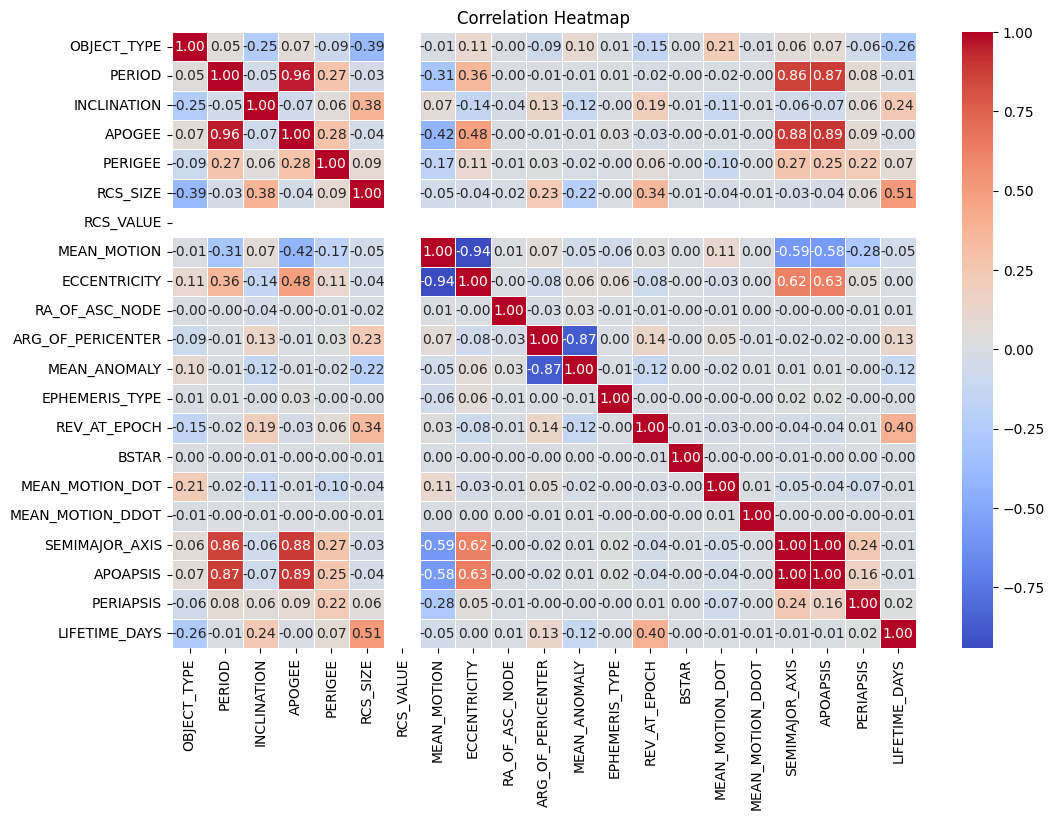

In [ ]:
# Calculate the correlation matrix
correlation_matrix = data.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Draw the heatmap with seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Set the title
plt.title('Correlation Heatmap')

# Display the heatmap
plt.show()


# Principal Component Analysis

Check and remove any missing rows before doing PCA

In [ ]:
data.isna().sum()

OBJECT_TYPE              0
PERIOD                  55
INCLINATION             55
APOGEE                  55
PERIGEE                 55
RCS_SIZE                 0
RCS_VALUE            29983
MEAN_MOTION              0
ECCENTRICITY             0
RA_OF_ASC_NODE           0
ARG_OF_PERICENTER        0
MEAN_ANOMALY             0
EPHEMERIS_TYPE           0
REV_AT_EPOCH             0
BSTAR                    0
MEAN_MOTION_DOT          0
MEAN_MOTION_DDOT         0
SEMIMAJOR_AXIS           0
APOAPSIS                 0
PERIAPSIS                0
LIFETIME_DAYS            0
dtype: int64

In [ ]:
data.shape

(29983, 21)

In [ ]:
# remove all rows which has PERIOD missing
data_PCA = data.dropna(subset=['PERIOD'])

In [ ]:
data_PCA.isna().sum()

OBJECT_TYPE              0
PERIOD                   0
INCLINATION              0
APOGEE                   0
PERIGEE                  0
RCS_SIZE                 0
RCS_VALUE            29928
MEAN_MOTION              0
ECCENTRICITY             0
RA_OF_ASC_NODE           0
ARG_OF_PERICENTER        0
MEAN_ANOMALY             0
EPHEMERIS_TYPE           0
REV_AT_EPOCH             0
BSTAR                    0
MEAN_MOTION_DOT          0
MEAN_MOTION_DDOT         0
SEMIMAJOR_AXIS           0
APOAPSIS                 0
PERIAPSIS                0
LIFETIME_DAYS            0
dtype: int64

In [ ]:
data_PCA = data_PCA.drop('RCS_VALUE', axis=1)

In [ ]:
data_PCA.shape

(29928, 20)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
# Remove non-numeric columns and the target variable
numeric_columns = data_PCA.select_dtypes(include=[np.number]).columns
features = [col for col in numeric_columns if col != 'LIFETIME_DAYS']
X = data_PCA[features]

In [ ]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [ ]:
# Explained Variance Ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

In [ ]:
# Print explained variance ratio
print("Explained Variance Ratio:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f}")

Explained Variance Ratio:
PC1: 0.3023
PC2: 0.2437
PC3: 0.1429
PC4: 0.1185
PC5: 0.1063
PC6: 0.0809
PC7: 0.0054


In [ ]:
# Print cumulative explained variance ratio
print("\nCumulative Explained Variance Ratio:")
for i, ratio in enumerate(cumulative_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f}")


Cumulative Explained Variance Ratio:
PC1: 0.3023
PC2: 0.5460
PC3: 0.6889
PC4: 0.8074
PC5: 0.9137
PC6: 0.9946
PC7: 1.0000


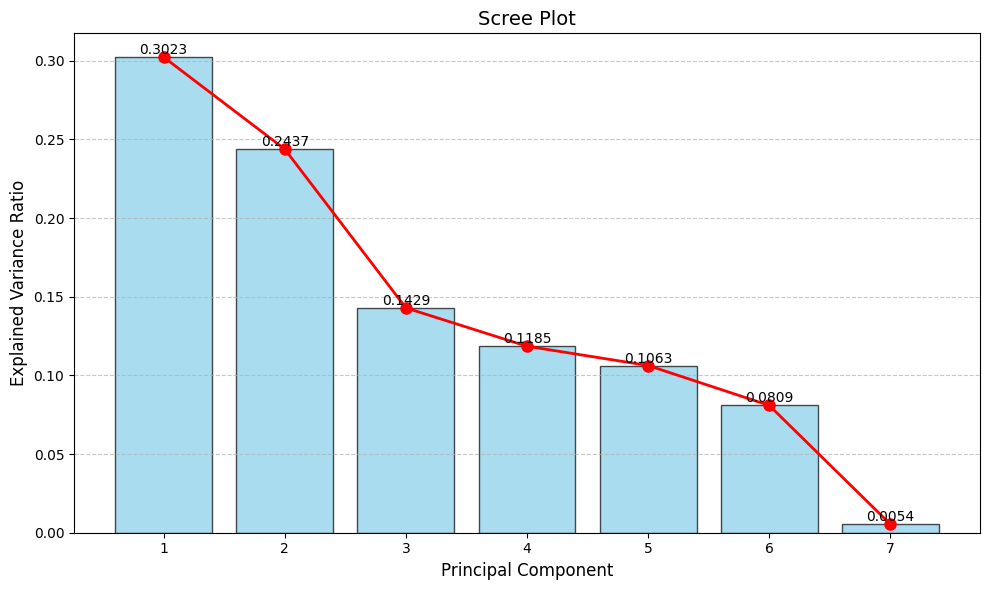

In [ ]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create the bar plot
bars = ax.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio,
              alpha=0.7, color='skyblue', edgecolor='black')

# Overlay the line plot
ax.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio,
        'ro-', linewidth=2, markersize=8)

# Customize the plot
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Explained Variance Ratio', fontsize=12)
ax.set_title('Scree Plot', fontsize=14)
ax.set_xticks(range(1, len(explained_variance_ratio) + 1))
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar
for i, v in enumerate(explained_variance_ratio):
    ax.text(i + 1, v, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

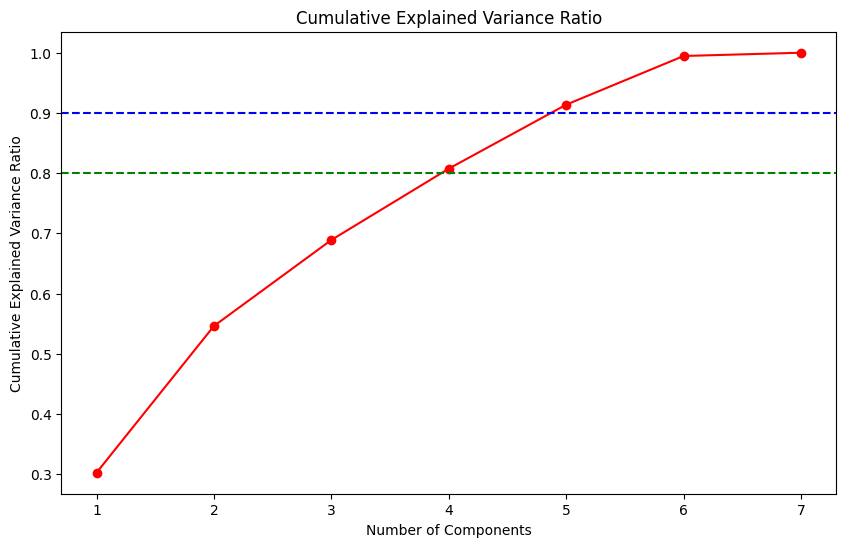

In [ ]:
# Cumulative Explained Variance Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, 'ro-')
plt.title('Cumulative Explained Variance Ratio')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.axhline(y=0.8, color='g', linestyle='--')
plt.axhline(y=0.9, color='b', linestyle='--')
plt.show()

Considering PC1, PC2, PC3 and PC4 should account for more than 80% of the variance in the data.

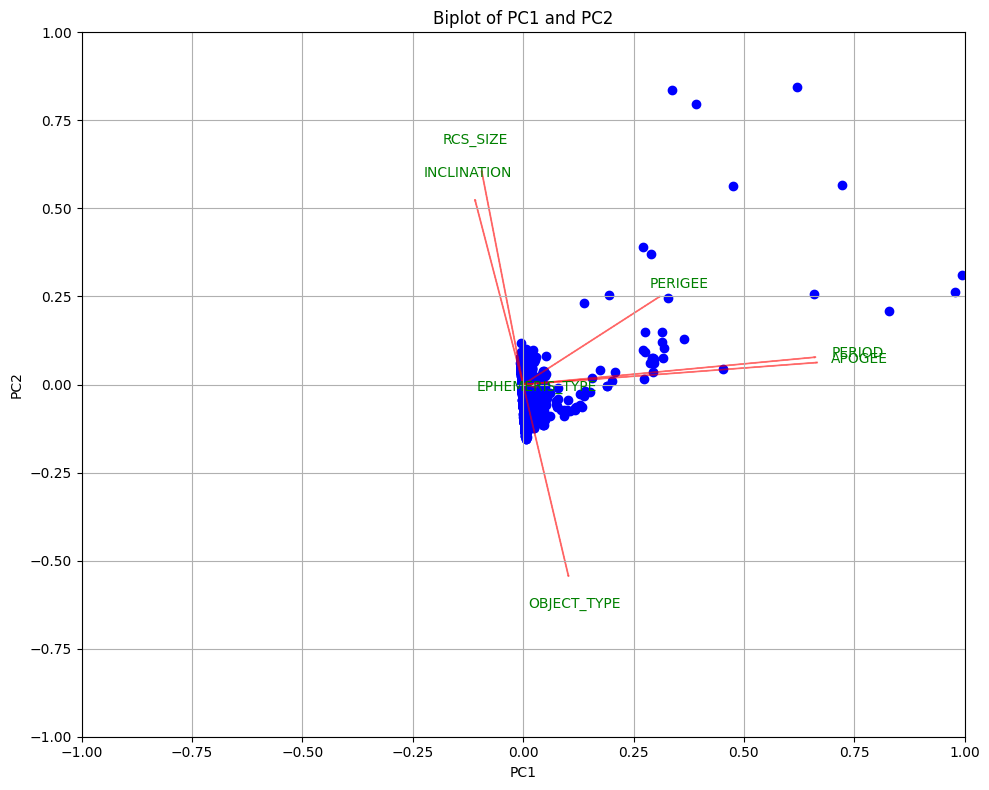

In [ ]:
def biplot(score, coeff, labels=None):
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    plt.scatter(xs * scalex,ys * scaley, c = 'blue')
    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1],color = 'r',alpha = 0.5)
        if labels is None:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), color = 'g', ha = 'center', va = 'center')
        else:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color = 'g', ha = 'center', va = 'center')
    plt.xlim(-1,1)
    plt.ylim(-1,1)
    plt.xlabel("PC{}".format(1))
    plt.ylabel("PC{}".format(2))
    plt.grid()

plt.figure(figsize=(10,8))
biplot(X_pca[:,0:2], np.transpose(pca.components_[0:2, :]), labels=features)
plt.title("Biplot of PC1 and PC2")
plt.tight_layout()
plt.show()

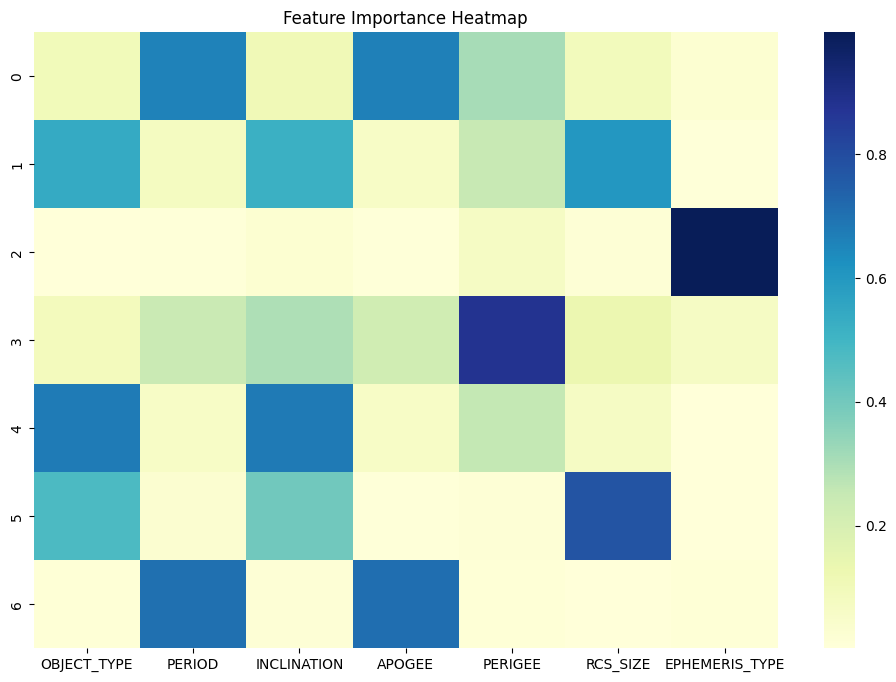

In [ ]:
# Feature Importance
pca_components = pd.DataFrame(abs(pca.components_), columns=features)
plt.figure(figsize=(12, 8))
sns.heatmap(pca_components, cmap='YlGnBu')
plt.title('Feature Importance Heatmap')
plt.show()

In [ ]:
# Print top features for each principal component
n_components = 7
for i in range(n_components):
    print(f"\nTop features for PC{i+1}:")
    top_features = pca_components.iloc[i].nlargest(5).index.tolist()
    for feature in top_features:
        print(f"{feature}: {pca_components.iloc[i][feature]:.4f}")



Top features for PC1:
APOGEE: 0.6631
PERIOD: 0.6590
PERIGEE: 0.3072
INCLINATION: 0.1085
OBJECT_TYPE: 0.1021

Top features for PC2:
RCS_SIZE: 0.6031
OBJECT_TYPE: 0.5412
INCLINATION: 0.5214
PERIGEE: 0.2481
PERIOD: 0.0773

Top features for PC3:
EPHEMERIS_TYPE: 0.9970
PERIGEE: 0.0701
INCLINATION: 0.0270
RCS_SIZE: 0.0149
PERIOD: 0.0093

Top features for PC4:
PERIGEE: 0.8795
INCLINATION: 0.2966
PERIOD: 0.2423
APOGEE: 0.2227
RCS_SIZE: 0.1309

Top features for PC5:
INCLINATION: 0.6803
OBJECT_TYPE: 0.6778
PERIGEE: 0.2555
RCS_SIZE: 0.0708
PERIOD: 0.0613

Top features for PC6:
RCS_SIZE: 0.7779
OBJECT_TYPE: 0.4785
INCLINATION: 0.4057
PERIOD: 0.0305
PERIGEE: 0.0172

Top features for PC7:
APOGEE: 0.7093
PERIOD: 0.7045
INCLINATION: 0.0157
EPHEMERIS_TYPE: 0.0131
OBJECT_TYPE: 0.0126


## Results
This output shows the top 5 contributing features for each of the 7 principal components (PCs) generated by the PCA. The numbers next to each feature represent the absolute value of the feature's coefficient in that principal component. Higher values indicate a stronger contribution to that PC.
Let's interpret each PC:

PC1:

Strongly influenced by APOGEE and PERIOD, with some contribution from PERIGEE.
This component likely represents the overall size of the orbit.


PC2:

Mainly influenced by RCS_SIZE, OBJECT_TYPE, and INCLINATION.
This might represent a combination of the object's physical characteristics and its orbital plane.


PC3:

Dominated by EPHEMERIS_TYPE.
This suggests that EPHEMERIS_TYPE varies independently from other features.


PC4:

Strongly influenced by PERIGEE, with some contribution from INCLINATION and PERIOD.
This could represent variations in the closest approach to Earth, possibly related to different types of orbits.


PC5:

Mainly influenced by INCLINATION and OBJECT_TYPE.
This might represent how different types of objects are placed in orbits with varying inclinations.


PC6:

Dominated by RCS_SIZE and OBJECT_TYPE.
This likely represents the physical size characteristics of different types of objects.


PC7:

Strongly influenced by APOGEE and PERIOD.
Similar to PC1, but capturing some residual variance in these features not explained by PC1.

## Inference


Some features (like APOGEE, PERIOD, INCLINATION, and OBJECT_TYPE) appear important across multiple PCs, indicating their significance in explaining the data's variance.
Other features (like EPHEMERIS_TYPE) are important for only one PC, suggesting they vary independently from other features.
The PCA has effectively grouped related features together. For example, APOGEE and PERIOD often appear together, which makes sense as they are related orbital characteristics.
Some features that were in the original dataset (like MEAN_MOTION, ECCENTRICITY, etc.) don't appear in the top 5 for any PC, indicating that their variance is either captured by combinations of other features or they contribute less to the overall variance in the dataset.
The order of PCs (1 to 7) represents decreasing importance in terms of explained variance. PC1 explains the most variance, PC2 the second most, and so on.

# Model

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [ ]:
# remove all rows which has PERIOD missing
data = data.dropna(subset=['PERIOD'])
# Select features based on PCA insights
selected_features = ['APOGEE', 'PERIOD', 'PERIGEE', 'RCS_SIZE', 'OBJECT_TYPE', 'INCLINATION', 'EPHEMERIS_TYPE']
X = data[selected_features]
y = data['LIFETIME_DAYS']
# Define numeric and categorical features based on column names
numeric_features = ['APOGEE', 'PERIOD', 'PERIGEE', 'RCS_SIZE', 'INCLINATION']
categorical_features = ['OBJECT_TYPE', 'EPHEMERIS_TYPE']
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train, y_train)
y_pred= rfr.predict(X_test)

In [ ]:
mean_absolute_error(y_pred, y_test)

1291.7760542823364

In [ ]:
mean_squared_error(y_pred, y_test)

5677228.764732818

In [ ]:
r2_score(y_pred, y_test)

0.6095921808244148

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Root Mean Squared Error: 2335.8445311854184
R-squared Score: 0.7134337781132882
Best parameters: {'rf__max_depth': 20, 'rf__max_features': 'auto', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 10, 'rf__n_estimators': 500}


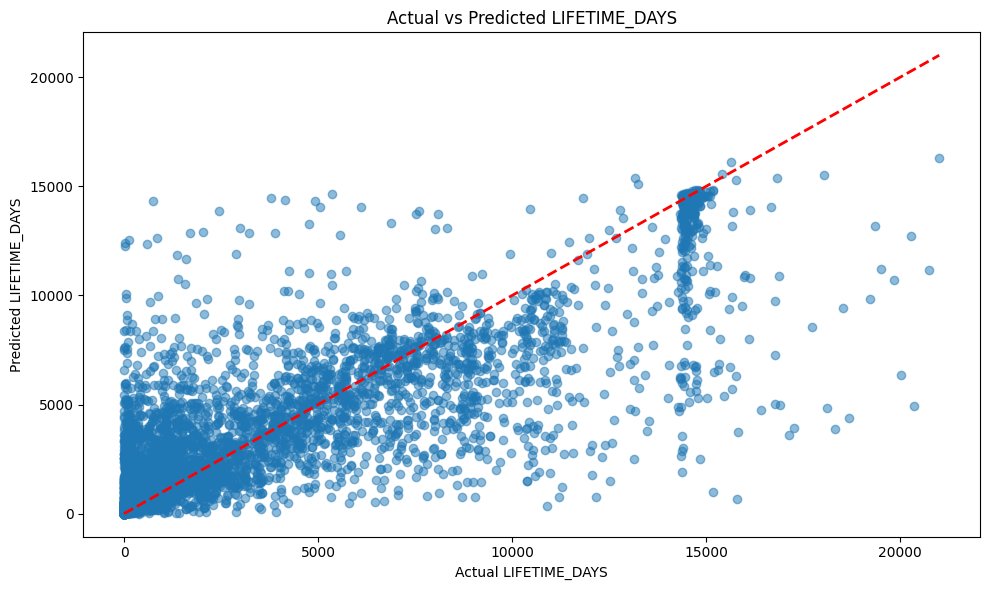

In [ ]:
# Create preprocessing steps
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Create the full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(random_state=42))
])

# Set up GridSearchCV
param_grid = {
    'rf__n_estimators': [100, 300, 500],
    'rf__max_depth': [10, 20, 30, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['auto', 'sqrt']
}

grid_search = GridSearchCV(pipeline, param_grid, cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit the model
grid_search.fit(X_train, y_train)

# Make predictions
y_pred = grid_search.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared Score: {r2}")
print(f"Best parameters: {grid_search.best_params_}")

# Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual LIFETIME_DAYS')
plt.ylabel('Predicted LIFETIME_DAYS')
plt.title('Actual vs Predicted LIFETIME_DAYS')
plt.tight_layout()
plt.show()

## Random forest with PCA

Mean Squared Error: 8300761.405269048
R-squared Score: 0.5640315501764269

PC Importance:
    PC  Importance
1  PC2    0.330990
2  PC3    0.229613
4  PC5    0.183405
0  PC1    0.137669
3  PC4    0.118322

Original Feature Importance:
              Feature  Importance
10       MEAN_ANOMALY    0.311557
9   ARG_OF_PERICENTER    0.311505
5            RCS_SIZE    0.265292
18          PERIAPSIS    0.227450
2         INCLINATION    0.223893
4             PERIGEE    0.215466
12       REV_AT_EPOCH    0.213793
0         OBJECT_TYPE    0.208601
7        ECCENTRICITY    0.173557
14    MEAN_MOTION_DOT    0.166635
1              PERIOD    0.155623
6         MEAN_MOTION    0.155190
3              APOGEE    0.142291
17           APOAPSIS    0.103159
16     SEMIMAJOR_AXIS    0.088768
11     EPHEMERIS_TYPE    0.061261
8      RA_OF_ASC_NODE    0.022544
13              BSTAR    0.022228
15   MEAN_MOTION_DDOT    0.007617


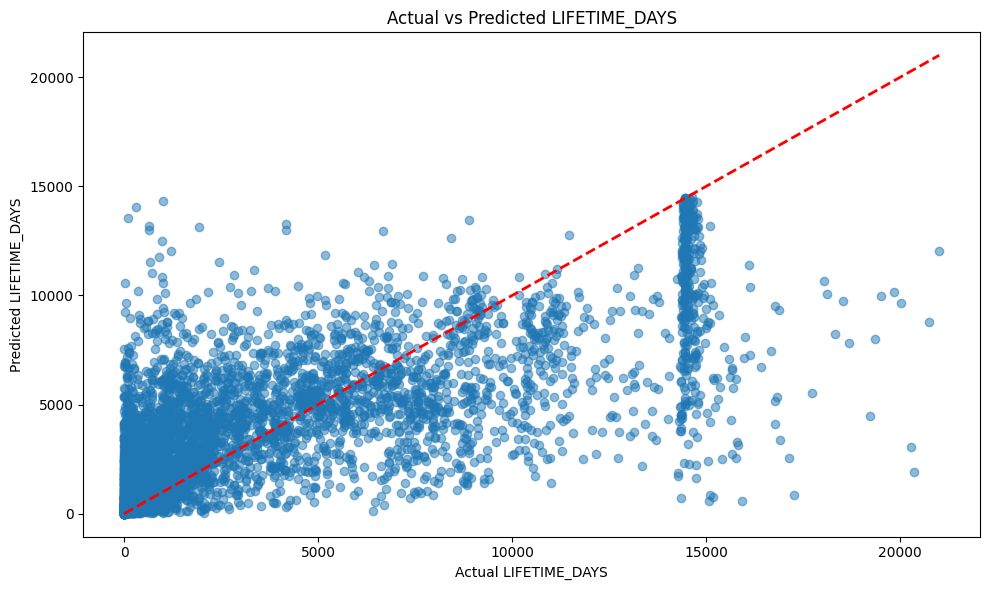

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


# Separate features and target
X = data_PCA.drop('LIFETIME_DAYS', axis=1)
y = data_PCA['LIFETIME_DAYS']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared Score:", r2)

# Feature importance (in terms of PCs)
pc_importance = pd.DataFrame({
    'PC': ['PC'+str(i+1) for i in range(5)],
    'Importance': rf_model.feature_importances_
})
pc_importance = pc_importance.sort_values('Importance', ascending=False)
print("\nPC Importance:")
print(pc_importance)

# Mapping back to original features
feature_importance = np.abs(pca.components_[:5].T).dot(rf_model.feature_importances_)
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
print("\nOriginal Feature Importance:")
print(feature_importance_df)

# Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual LIFETIME_DAYS')
plt.ylabel('Predicted LIFETIME_DAYS')
plt.title('Actual vs Predicted LIFETIME_DAYS')
plt.tight_layout()
plt.show()

## Other models

Fitting 3 folds for each of 216 candidates, totalling 648 fits

Random Forest Regression Results:
Root Mean Squared Error: 2335.8445311854184
R-squared Score: 0.7134337781132882
Best parameters: {'model__max_depth': 20, 'model__max_features': 'auto', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 500}


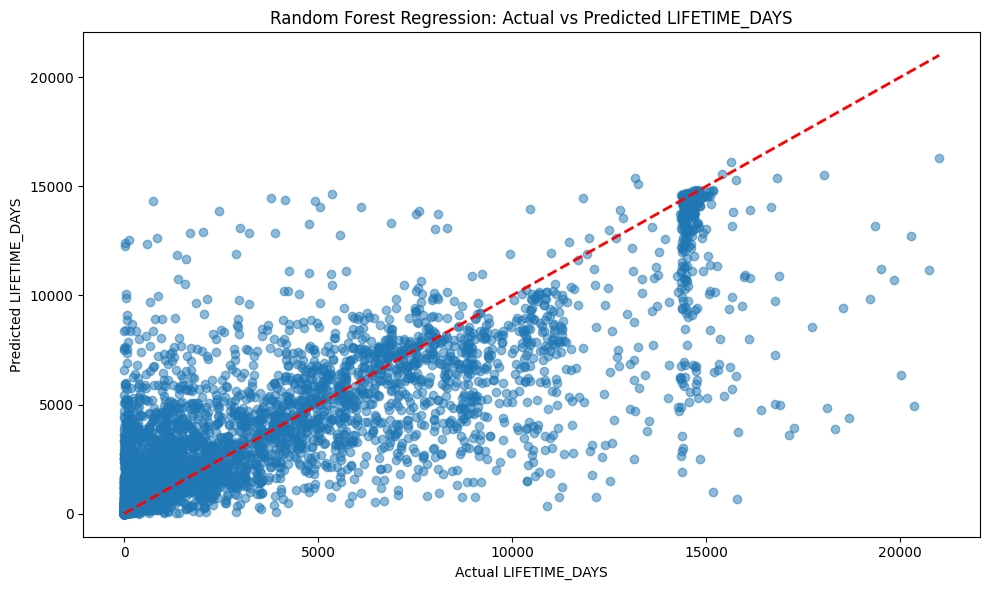

Fitting 3 folds for each of 243 candidates, totalling 729 fits

Gradient Boosting Regression Results:
Root Mean Squared Error: 2413.874606553137
R-squared Score: 0.6939682098605774
Best parameters: {'model__learning_rate': 0.2, 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 200}


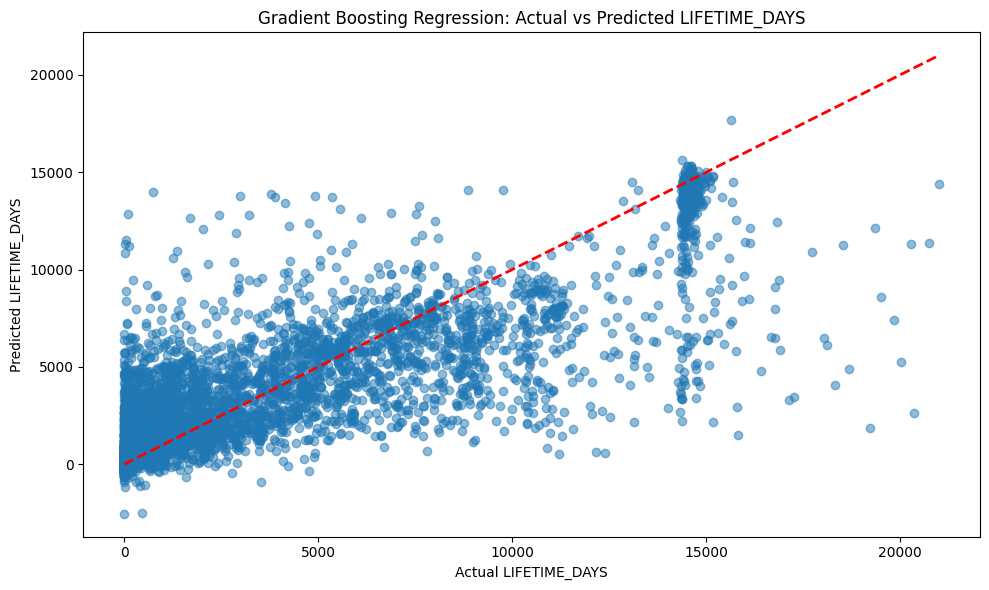

Fitting 3 folds for each of 27 candidates, totalling 81 fits

Elastic Net Regression Results:
Root Mean Squared Error: 3776.661094519856
R-squared Score: 0.25087695153836387
Best parameters: {'model__alpha': 0.1, 'model__l1_ratio': 0.9, 'model__max_iter': 1000}


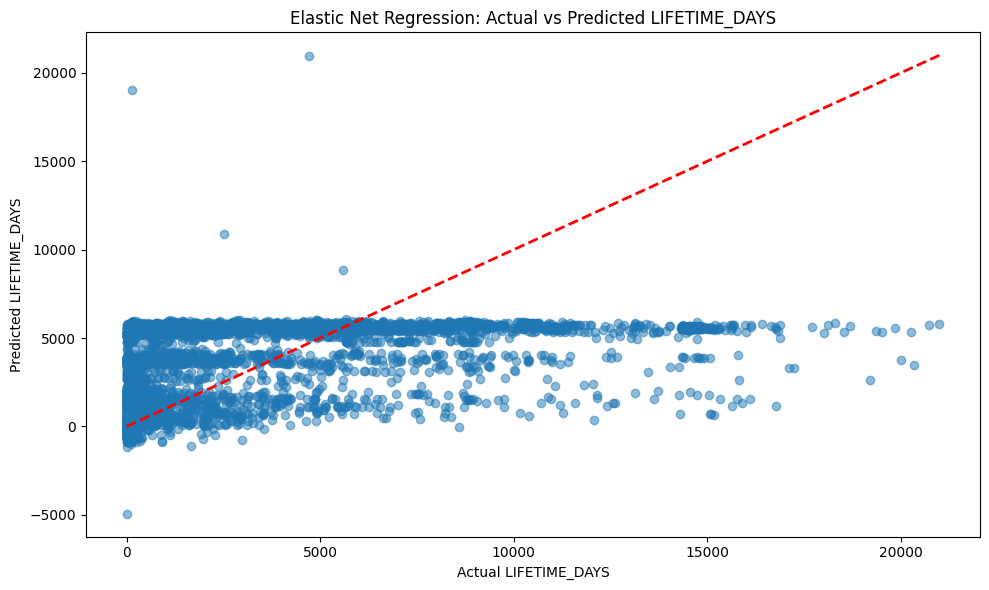

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Ridge Regression Results:
Root Mean Squared Error: 3776.949089477846
R-squared Score: 0.2507626961781927
Best parameters: {'model__alpha': 100, 'model__max_iter': 1000}


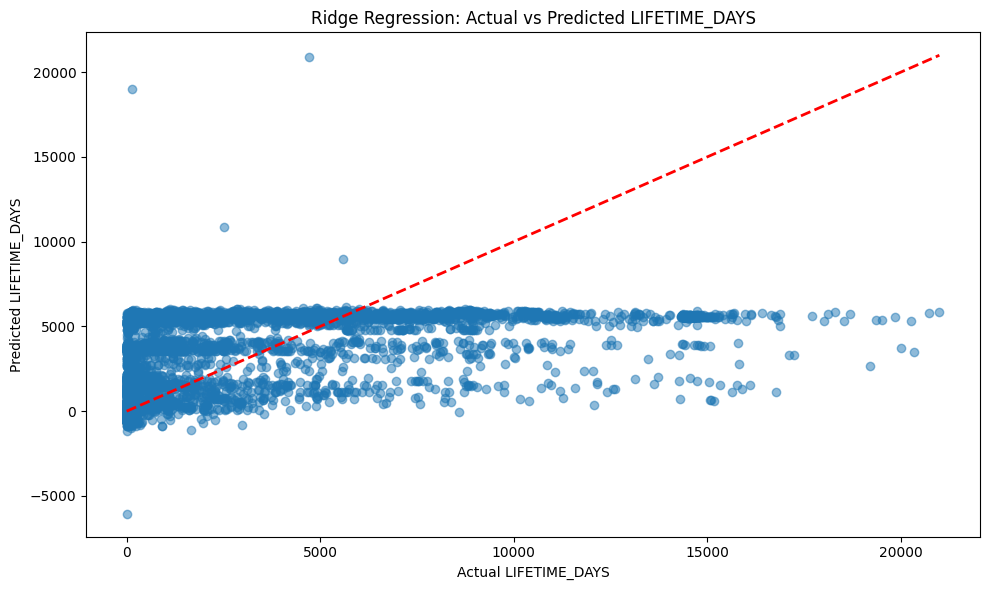

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Lasso Regression Results:
Root Mean Squared Error: 3776.952216824472
R-squared Score: 0.2507614554276987
Best parameters: {'model__alpha': 1, 'model__max_iter': 1000}


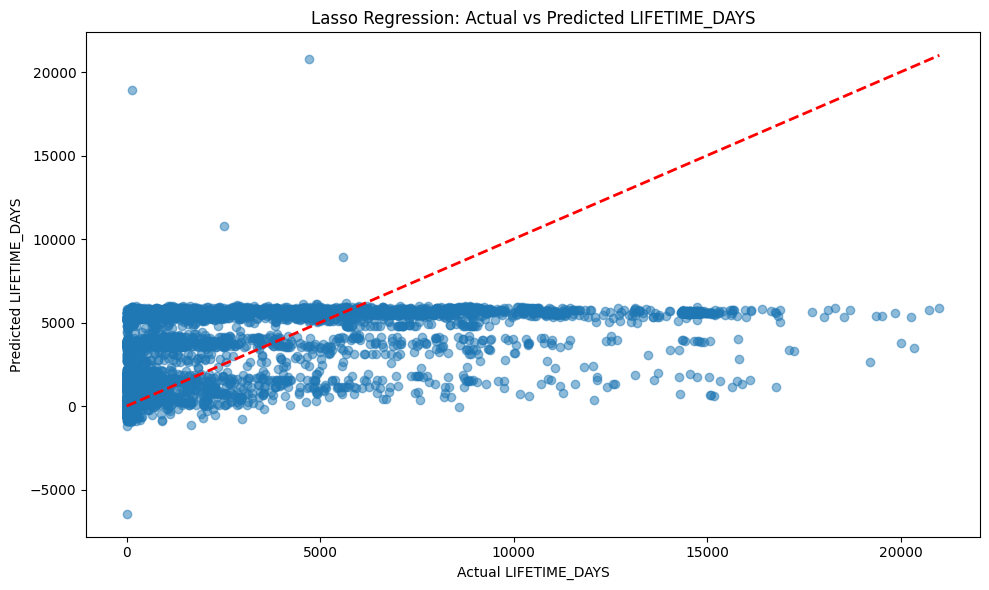

Fitting 3 folds for each of 16 candidates, totalling 48 fits

K-Nearest Neighbors Regression Results:
Root Mean Squared Error: 2536.938160104892
R-squared Score: 0.661968717829357
Best parameters: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'distance'}


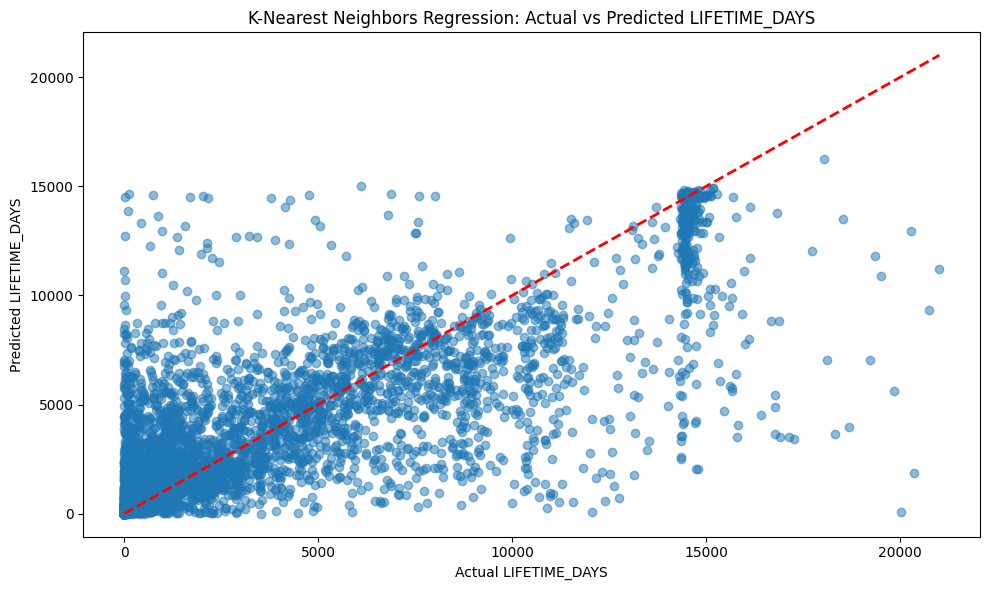


Polynomial Regression (degree=2) Results:
Root Mean Squared Error: 3955.7702325088226
R-squared Score: 0.1781373452669769


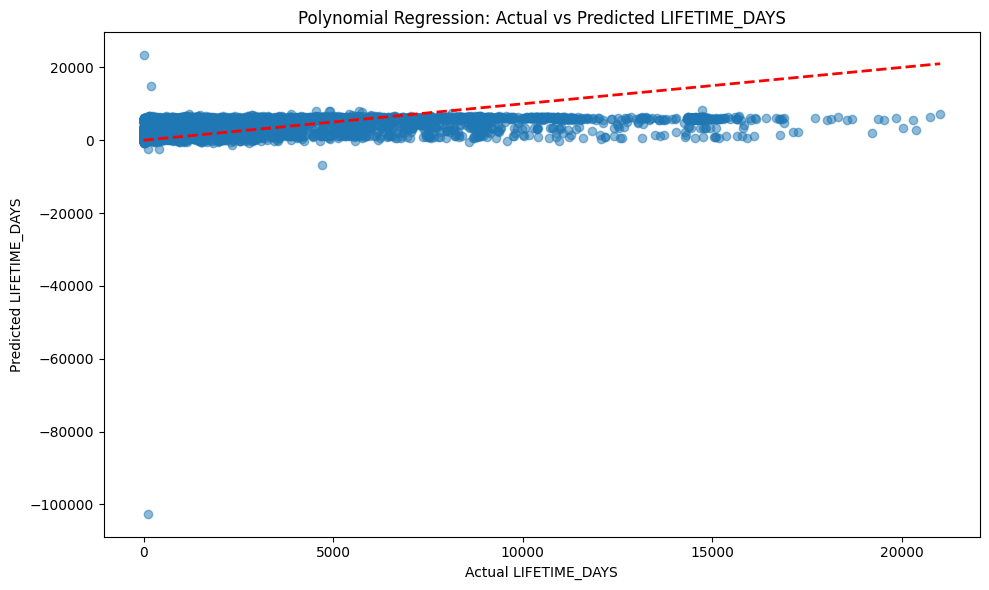

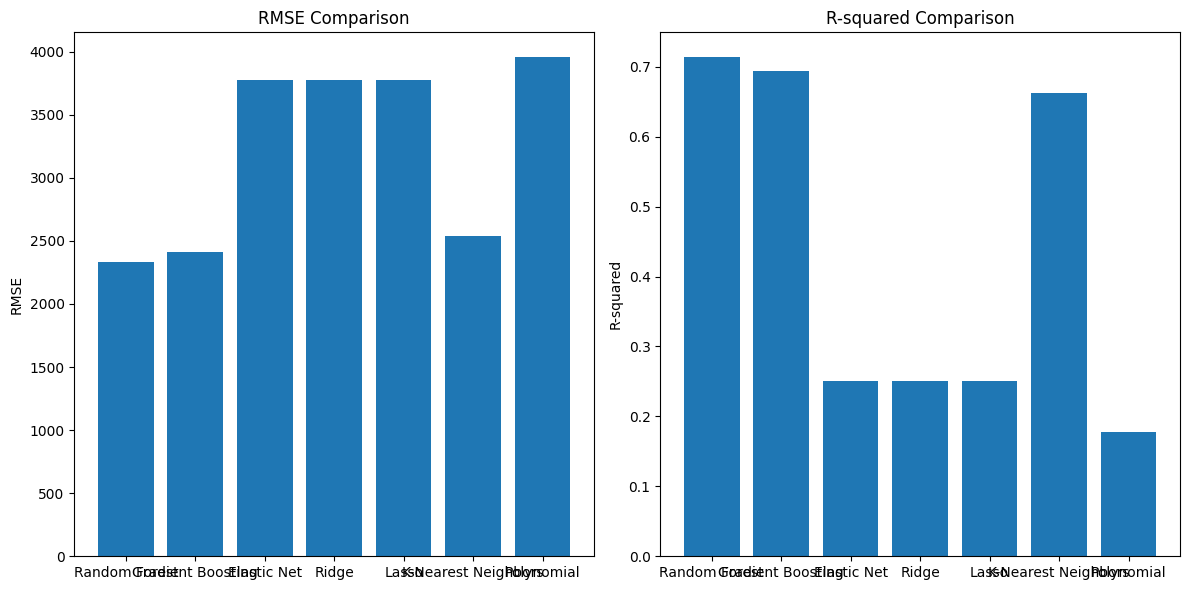


Model Comparison:
Random Forest: RMSE = 2335.8445, R-squared = 0.7134
Gradient Boosting: RMSE = 2413.8746, R-squared = 0.6940
Elastic Net: RMSE = 3776.6611, R-squared = 0.2509
Ridge: RMSE = 3776.9491, R-squared = 0.2508
Lasso: RMSE = 3776.9522, R-squared = 0.2508
K-Nearest Neighbors: RMSE = 2536.9382, R-squared = 0.6620
Polynomial: RMSE = 3955.7702, R-squared = 0.1781


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import ElasticNet, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor

# remove all rows which has PERIOD missing
data = data.dropna(subset=['PERIOD'])

# Select features based on PCA insights
selected_features = ['APOGEE', 'PERIOD', 'PERIGEE', 'RCS_SIZE', 'OBJECT_TYPE', 'INCLINATION', 'EPHEMERIS_TYPE']
X = data[selected_features]
y = data['LIFETIME_DAYS']

# Define numeric and categorical features based on column names
numeric_features = ['APOGEE', 'PERIOD', 'PERIGEE', 'RCS_SIZE', 'INCLINATION']
categorical_features = ['OBJECT_TYPE', 'EPHEMERIS_TYPE']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create preprocessing steps
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Function to create and evaluate a model
def create_and_evaluate_model(model, param_grid, X_train, X_test, y_train, y_test, model_name):
    # Create the full pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Set up GridSearchCV
    grid_search = GridSearchCV(pipeline, param_grid, cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

    # Fit the model
    grid_search.fit(X_train, y_train)

    # Make predictions
    y_pred = grid_search.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name} Results:")
    print(f"Root Mean Squared Error: {rmse}")
    print(f"R-squared Score: {r2}")
    print(f"Best parameters: {grid_search.best_params_}")

    # Visualize actual vs predicted values
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual LIFETIME_DAYS')
    plt.ylabel('Predicted LIFETIME_DAYS')
    plt.title(f'{model_name}: Actual vs Predicted LIFETIME_DAYS')
    plt.tight_layout()
    plt.show()

    return grid_search, rmse, r2

# Function to create and evaluate Polynomial Regression (with Linear Regression)
def create_and_evaluate_polynomial_model(degree, X_train, X_test, y_train, y_test):
    poly_features = PolynomialFeatures(degree=degree)
    X_train_poly = poly_features.fit_transform(X_train)
    X_test_poly = poly_features.transform(X_test)

    model = Ridge()  # or any other regressor like LinearRegression or Ridge
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\nPolynomial Regression (degree={degree}) Results:")
    print(f"Root Mean Squared Error: {rmse}")
    print(f"R-squared Score: {r2}")

    # Visualize actual vs predicted values
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual LIFETIME_DAYS')
    plt.ylabel('Predicted LIFETIME_DAYS')
    plt.title(f'Polynomial Regression: Actual vs Predicted LIFETIME_DAYS')
    plt.tight_layout()
    plt.show()

    return model, rmse, r2

# 1. Random Forest Regression
rf_param_grid = {
    'model__n_estimators': [100, 300, 500],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['auto', 'sqrt']
}
rf_model, rf_rmse, rf_r2 = create_and_evaluate_model(RandomForestRegressor(random_state=42), rf_param_grid, X_train, X_test, y_train, y_test, "Random Forest Regression")

# 2. Gradient Boosting Regression
gb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 4, 5],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}
gb_model, gb_rmse, gb_r2 = create_and_evaluate_model(GradientBoostingRegressor(random_state=42), gb_param_grid, X_train, X_test, y_train, y_test, "Gradient Boosting Regression")

# 3. Elastic Net Regression
en_param_grid = {
    'model__alpha': [0.1, 1, 10],
    'model__l1_ratio': [0.1, 0.5, 0.9],
    'model__max_iter': [1000, 2000, 5000]
}
en_model, en_rmse, en_r2 = create_and_evaluate_model(ElasticNet(random_state=42), en_param_grid, X_train, X_test, y_train, y_test, "Elastic Net Regression")

# 4. Ridge Regression
ridge_param_grid = {
    'model__alpha': [0.1, 1, 10, 100],
    'model__max_iter': [1000, 2000, 5000]
}
ridge_model, ridge_rmse, ridge_r2 = create_and_evaluate_model(Ridge(random_state=42), ridge_param_grid, X_train, X_test, y_train, y_test, "Ridge Regression")

# 5. Lasso Regression
lasso_param_grid = {
    'model__alpha': [0.01, 0.1, 1, 10],
    'model__max_iter': [1000, 2000, 5000]
}
lasso_model, lasso_rmse, lasso_r2 = create_and_evaluate_model(Lasso(random_state=42), lasso_param_grid, X_train, X_test, y_train, y_test, "Lasso Regression")

# 6. K-Nearest Neighbors Regression
knn_param_grid = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]  # p=1: Manhattan, p=2: Euclidean distance
}
knn_model, knn_rmse, knn_r2 = create_and_evaluate_model(KNeighborsRegressor(), knn_param_grid, X_train, X_test, y_train, y_test, "K-Nearest Neighbors Regression")

# 7. Polynomial Regression (degree=2)
poly_model, poly_rmse, poly_r2 = create_and_evaluate_polynomial_model(2, X_train, X_test, y_train, y_test)

# Compare all models
models = ["Random Forest", "Gradient Boosting", "Elastic Net", "Ridge", "Lasso", "K-Nearest Neighbors", "Polynomial"]
rmse_scores = [rf_rmse, gb_rmse, en_rmse, ridge_rmse, lasso_rmse, knn_rmse, poly_rmse]
r2_scores = [rf_r2, gb_r2, en_r2, ridge_r2, lasso_r2, knn_r2, poly_r2]

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(models, rmse_scores)
plt.title("RMSE Comparison")
plt.ylabel("RMSE")

plt.subplot(1, 2, 2)
plt.bar(models, r2_scores)
plt.title("R-squared Comparison")
plt.ylabel("R-squared")

plt.tight_layout()
plt.show()

print("\nModel Comparison:")
for model, rmse, r2 in zip(models, rmse_scores, r2_scores):
    print(f"{model}: RMSE = {rmse:.4f}, R-squared = {r2:.4f}")

## As a classification problem

### Data prep

In [ ]:
# Remove all rows which has PERIOD missing
data = data.dropna(subset=['PERIOD'])

def plot_confusion_matrix(y_true, y_pred, classes, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))

    # Create a heatmap with both colors and numbers
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, cbar=True)

    plt.title(f'Confusion Matrix - {model_name}', fontsize=16)
    plt.ylabel('True label', fontsize=12)
    plt.xlabel('Predicted label', fontsize=12)

    # Calculate and display accuracy for each class
    class_accuracies = cm.diagonal() / cm.sum(axis=1)
    for i, accuracy in enumerate(class_accuracies):
        plt.text(i+0.5, len(classes)+0.1, f'{accuracy:.2%}',
                 horizontalalignment='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print classification metrics
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))

    # Calculate and print overall accuracy
    overall_accuracy = np.trace(cm) / np.sum(cm)
    print(f"\nOverall Accuracy: {overall_accuracy:.2%}")

# Function to categorize LIFETIME_DAYS
def categorize_lifetime(days):
    if days <= 365:
        return 'Short-lived'
    elif days <= 1825:  # 5 years
        return 'Medium-lived'
    else:
        return 'Long-lived'

# Create new target variable
data['LIFETIME_CATEGORY'] = data['LIFETIME_DAYS'].apply(categorize_lifetime)

# Select features based on PCA insights
selected_features = ['APOGEE', 'PERIOD', 'PERIGEE', 'RCS_SIZE', 'OBJECT_TYPE', 'INCLINATION', 'EPHEMERIS_TYPE']
X = data[selected_features]
y = data['LIFETIME_CATEGORY']

# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create preprocessing steps
numeric_features = ['APOGEE', 'PERIOD', 'PERIGEE', 'RCS_SIZE', 'INCLINATION']
categorical_features = ['OBJECT_TYPE', 'EPHEMERIS_TYPE']

### Classes distribution

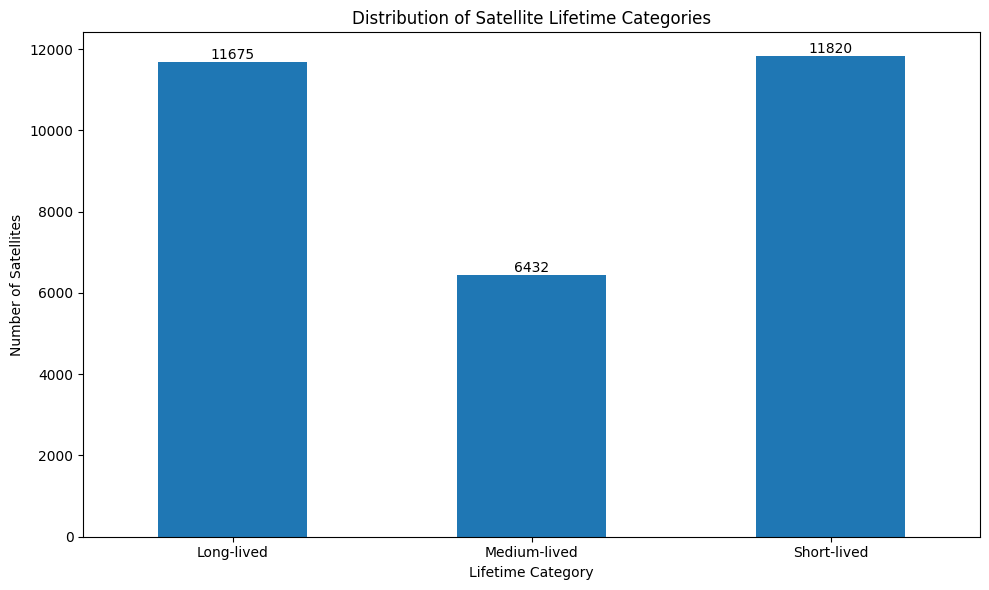

Long-lived: 11675 (39.01%)
Medium-lived: 6432 (21.49%)
Short-lived: 11820 (39.50%)


In [ ]:
# Count the number of instances in each class
class_counts = data['LIFETIME_CATEGORY'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar')
plt.title('Distribution of Satellite Lifetime Categories')
plt.xlabel('Lifetime Category')
plt.ylabel('Number of Satellites')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability

# Add value labels on top of each bar
for i, v in enumerate(class_counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print the exact counts and percentages
total = len(data)
for category, count in class_counts.items():
    percentage = count / total * 100
    print(f"{category}: {count} ({percentage:.2f}%)")

### Train models

Fitting 3 folds for each of 108 candidates, totalling 324 fits

Random Forest Results:
Accuracy: 0.7933511526896091
Best parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 300}

Classification Report:
              precision    recall  f1-score   support

  Long-lived       0.78      0.87      0.82      2292
Medium-lived       0.72      0.52      0.61      1361
 Short-lived       0.84      0.88      0.86      2333

    accuracy                           0.79      5986
   macro avg       0.78      0.76      0.76      5986
weighted avg       0.79      0.79      0.79      5986



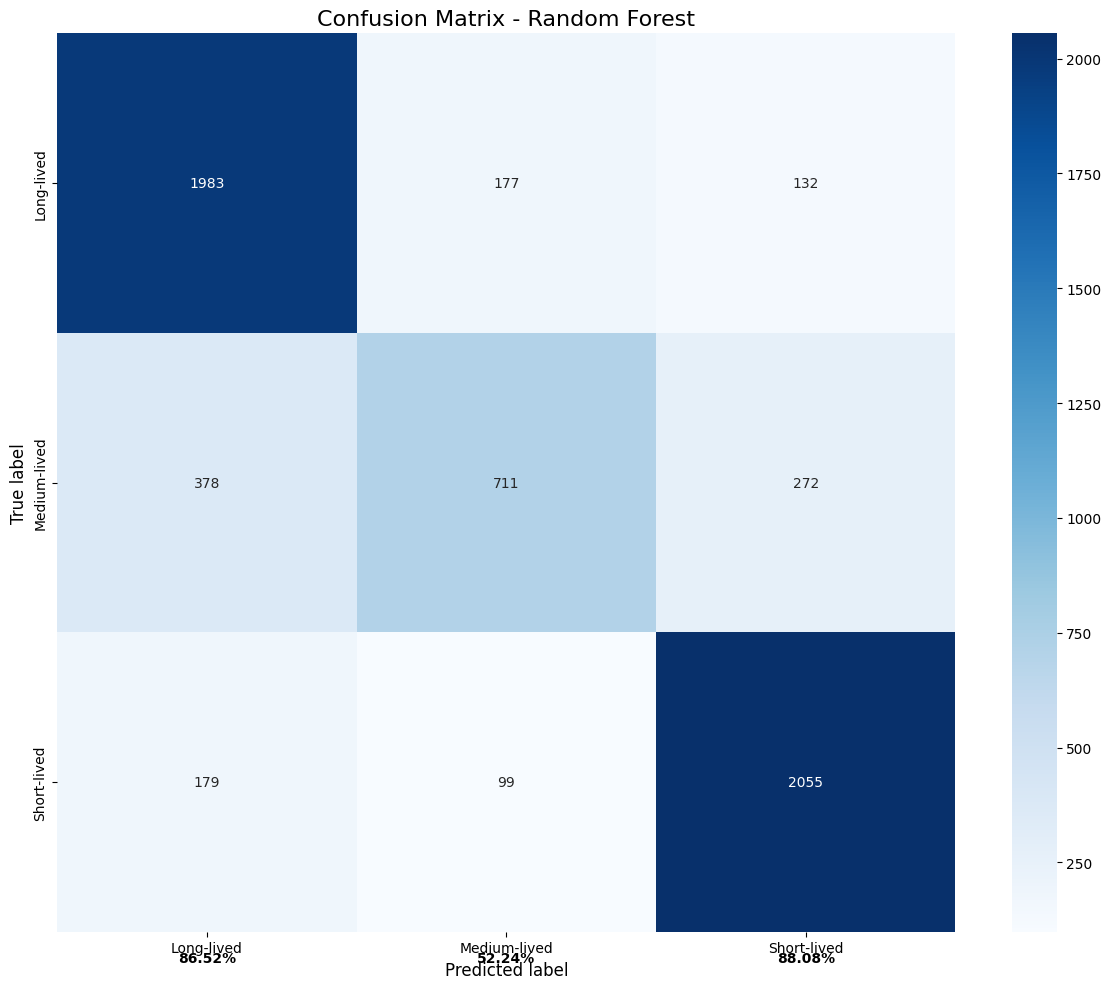


Classification Report:
              precision    recall  f1-score   support

  Long-lived       0.78      0.87      0.82      2292
Medium-lived       0.72      0.52      0.61      1361
 Short-lived       0.84      0.88      0.86      2333

    accuracy                           0.79      5986
   macro avg       0.78      0.76      0.76      5986
weighted avg       0.79      0.79      0.79      5986


Overall Accuracy: 79.34%
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Support Vector Machine Results:
Accuracy: 0.6886067490811895
Best parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Classification Report:
              precision    recall  f1-score   support

  Long-lived       0.67      0.83      0.74      2292
Medium-lived       0.62      0.16      0.25      1361
 Short-lived       0.72      0.86      0.78      2333

    accuracy                           0.69      5986
   macro avg       0.67      0.62      0.59      5986
weighted avg 

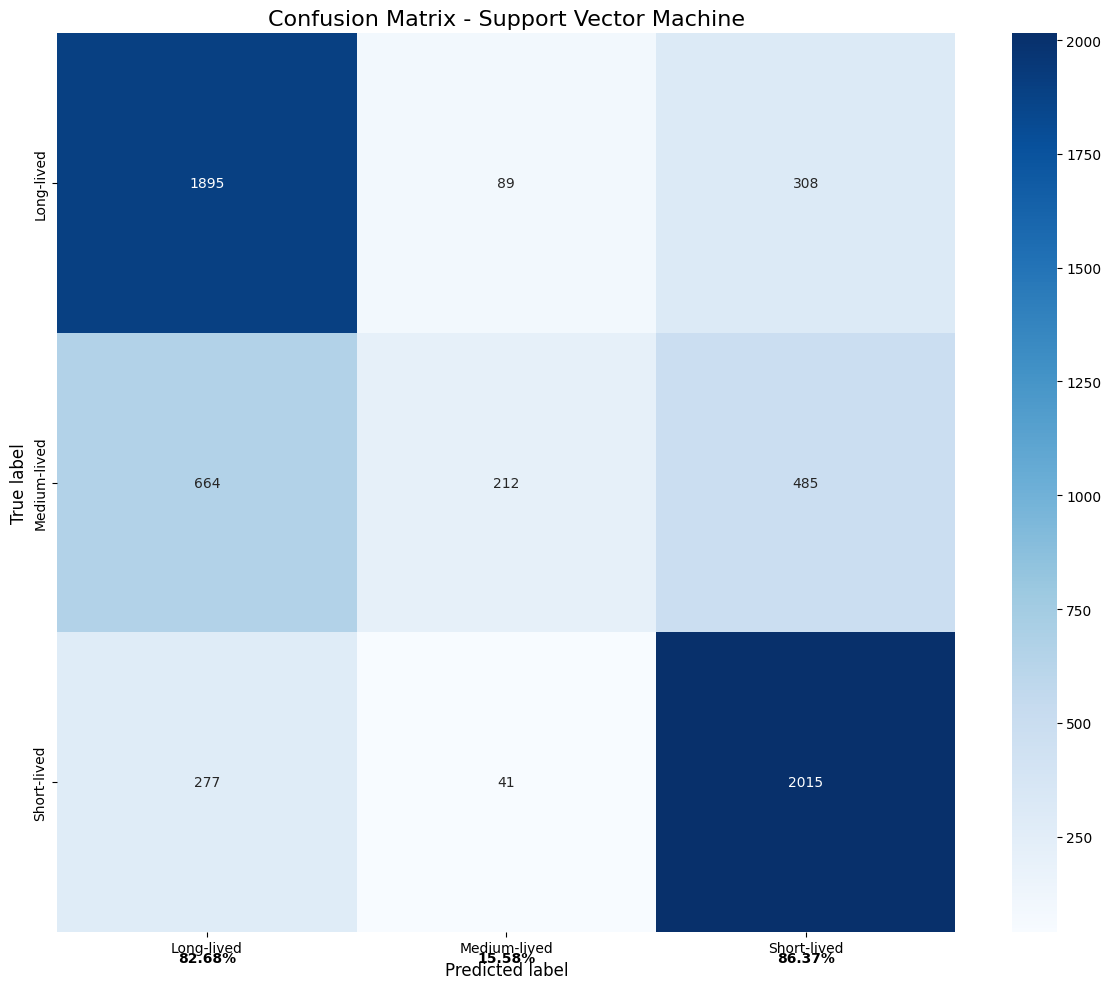


Classification Report:
              precision    recall  f1-score   support

  Long-lived       0.67      0.83      0.74      2292
Medium-lived       0.62      0.16      0.25      1361
 Short-lived       0.72      0.86      0.78      2333

    accuracy                           0.69      5986
   macro avg       0.67      0.62      0.59      5986
weighted avg       0.68      0.69      0.65      5986


Overall Accuracy: 68.86%
Fitting 3 folds for each of 16 candidates, totalling 48 fits

K-Nearest Neighbors Results:
Accuracy: 0.7846642165051787
Best parameters: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'distance'}

Classification Report:
              precision    recall  f1-score   support

  Long-lived       0.79      0.82      0.80      2292
Medium-lived       0.65      0.58      0.61      1361
 Short-lived       0.85      0.87      0.86      2333

    accuracy                           0.78      5986
   macro avg       0.76      0.76      0.76      5986
weighted av

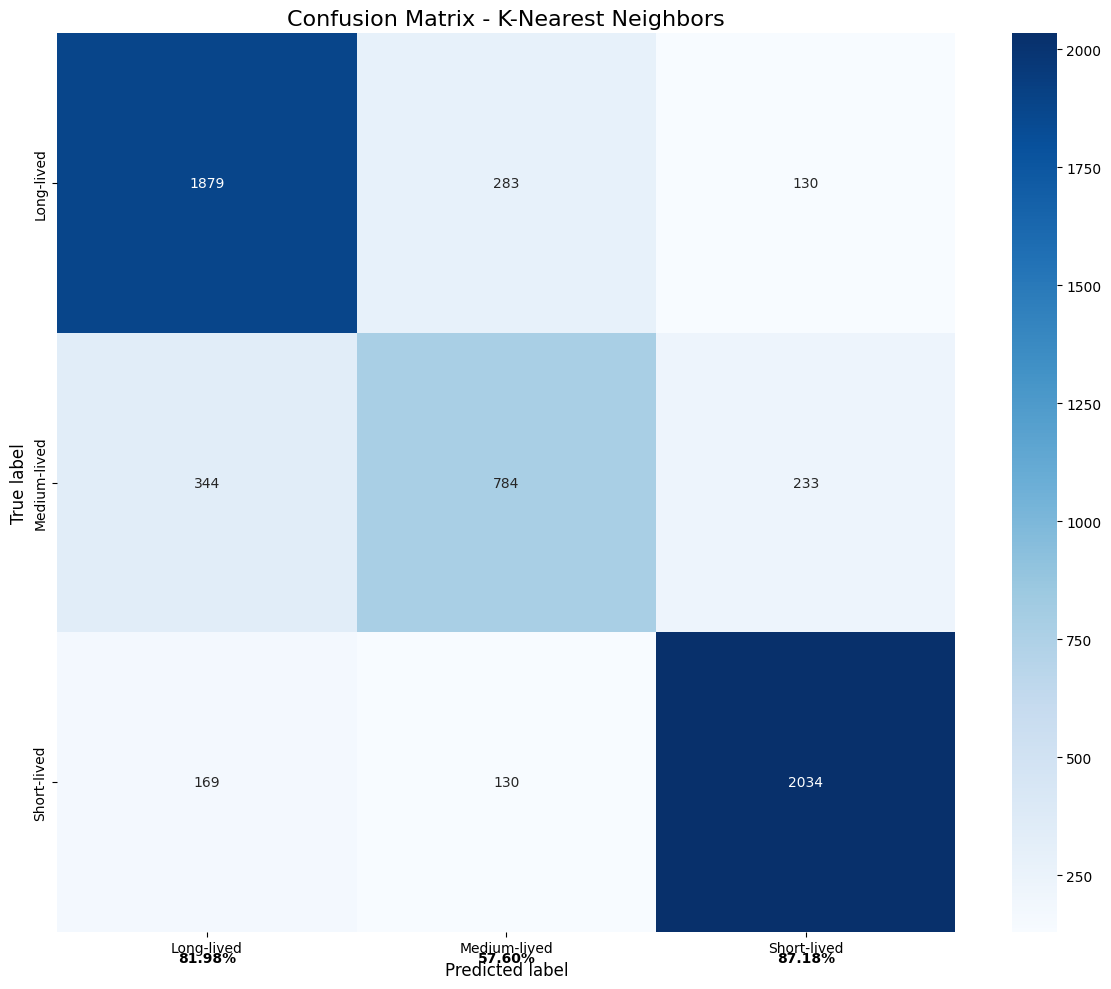


Classification Report:
              precision    recall  f1-score   support

  Long-lived       0.79      0.82      0.80      2292
Medium-lived       0.65      0.58      0.61      1361
 Short-lived       0.85      0.87      0.86      2333

    accuracy                           0.78      5986
   macro avg       0.76      0.76      0.76      5986
weighted avg       0.78      0.78      0.78      5986


Overall Accuracy: 78.47%
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Logistic Regression Results:
Accuracy: 0.6426662211827597
Best parameters: {'model__C': 10, 'model__max_iter': 1000, 'model__solver': 'lbfgs'}

Classification Report:
              precision    recall  f1-score   support

  Long-lived       0.60      0.84      0.70      2292
Medium-lived       0.49      0.01      0.03      1361
 Short-lived       0.70      0.81      0.75      2333

    accuracy                           0.64      5986
   macro avg       0.59      0.56      0.49      5986
weighted avg  

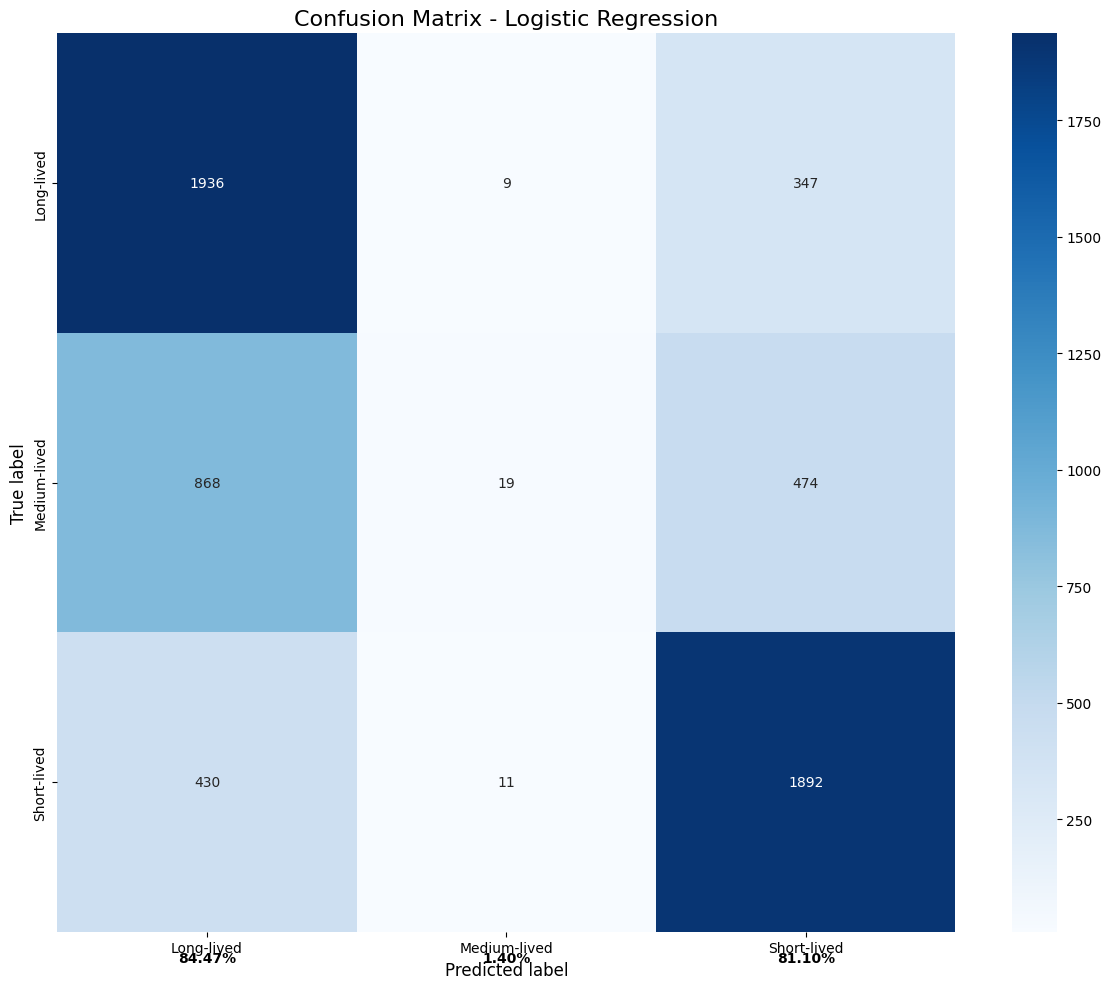


Classification Report:
              precision    recall  f1-score   support

  Long-lived       0.60      0.84      0.70      2292
Medium-lived       0.49      0.01      0.03      1361
 Short-lived       0.70      0.81      0.75      2333

    accuracy                           0.64      5986
   macro avg       0.59      0.56      0.49      5986
weighted avg       0.61      0.64      0.57      5986


Overall Accuracy: 64.27%


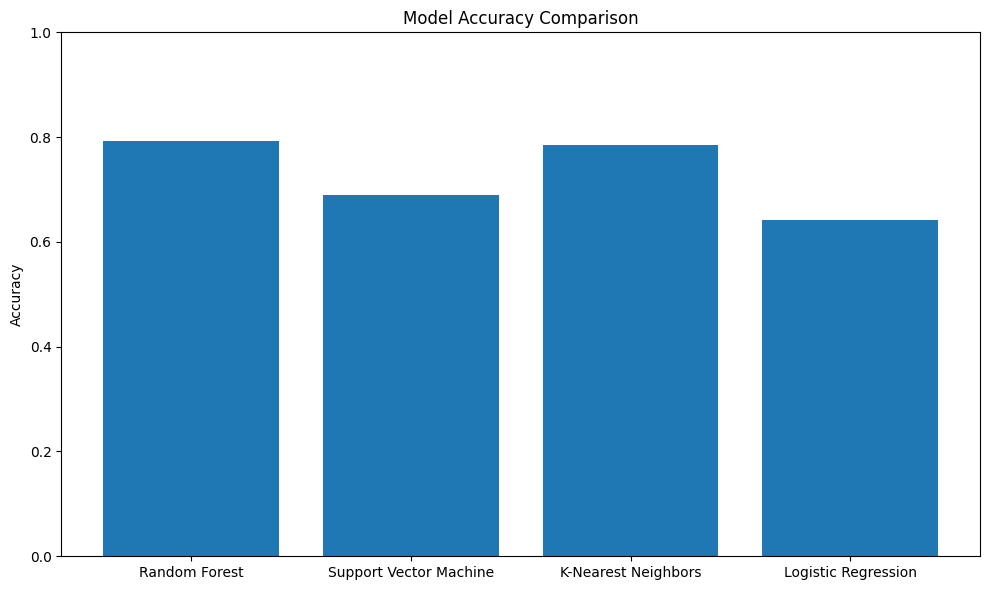


Model Comparison:
Random Forest: Accuracy = 0.7934
Support Vector Machine: Accuracy = 0.6886
K-Nearest Neighbors: Accuracy = 0.7847
Logistic Regression: Accuracy = 0.6427


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Function to create and evaluate a model
def create_and_evaluate_model(model, param_grid, X_train, X_test, y_train, y_test, model_name):
    # Create the full pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Set up GridSearchCV
    grid_search = GridSearchCV(pipeline, param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

    # Fit the model
    grid_search.fit(X_train, y_train)

    # Make predictions
    y_pred = grid_search.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n{model_name} Results:")
    print(f"Accuracy: {accuracy}")
    print(f"Best parameters: {grid_search.best_params_}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Plot confusion matrix
    plot_confusion_matrix(y_test, y_pred, le.classes_, model_name)

    return grid_search, accuracy

# Define and evaluate models
# Random Forest
rf_param_grid = {
    'model__n_estimators': [100, 300, 500],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}
rf_model, rf_accuracy = create_and_evaluate_model(RandomForestClassifier(random_state=42), rf_param_grid, X_train, X_test, y_train, y_test, "Random Forest")

# Support Vector Machine
svm_param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf', 'linear'],
    'model__gamma': ['scale', 'auto']
}
svm_model, svm_accuracy = create_and_evaluate_model(SVC(random_state=42), svm_param_grid, X_train, X_test, y_train, y_test, "Support Vector Machine")

# K-Nearest Neighbors
knn_param_grid = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}
knn_model, knn_accuracy = create_and_evaluate_model(KNeighborsClassifier(), knn_param_grid, X_train, X_test, y_train, y_test, "K-Nearest Neighbors")

# Logistic Regression
lr_param_grid = {
    'model__C': [0.1, 1, 10],
    'model__solver': ['lbfgs', 'liblinear'],
    'model__max_iter': [1000, 2000, 5000]
}
lr_model, lr_accuracy = create_and_evaluate_model(LogisticRegression(random_state=42), lr_param_grid, X_train, X_test, y_train, y_test, "Logistic Regression")

# Compare all models
models = ["Random Forest", "Support Vector Machine", "K-Nearest Neighbors", "Logistic Regression"]
accuracies = [rf_accuracy, svm_accuracy, knn_accuracy, lr_accuracy]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("\nModel Comparison:")
for model, accuracy in zip(models, accuracies):
    print(f"{model}: Accuracy = {accuracy:.4f}")

### Observation
### Model Performance Summary

| Model                   | Accuracy |
|-------------------------|----------|
| Random Forest           | 79.34%   |
| Support Vector Machine  | 68.86%   |
| K-Nearest Neighbors     | 78.47%   |
| Logistic Regression     | 64.27%   |

### Detailed Observations

#### Random Forest
- Best overall performance with 79.34% accuracy
- Good balance between precision and recall for all classes
- Strong performance on Long-lived (87% recall) and Short-lived (88% recall) classes
- Slightly lower performance on Medium-lived class (52% recall)

#### Support Vector Machine
- Overall accuracy of 68.86%
- Strong performance on Long-lived (83% recall) and Short-lived (86% recall) classes
- Very poor performance on Medium-lived class (16% recall)
- Tends to misclassify Medium-lived satellites as either Long-lived or Short-lived

#### K-Nearest Neighbors
- Second-best performer with 78.47% accuracy
- Good balance across all classes
- Consistent performance for Long-lived (82% recall) and Short-lived (87% recall) classes
- Improved performance on Medium-lived class (58% recall) compared to other models

#### Logistic Regression
- Lowest overall accuracy at 64.27%
- Strong recall for Long-lived (84%) and Short-lived (81%) classes
- Extremely poor performance on Medium-lived class (1% recall)
- Tends to classify most satellites as either Long-lived or Short-lived

### General Observations
1. All models struggle with the Medium-lived class, suggesting this category is the most challenging to predict accurately.
2. Random Forest and K-Nearest Neighbors provide the most balanced performance across all classes.
3. Support Vector Machine and Logistic Regression show a strong bias towards Long-lived and Short-lived classes, often misclassifying Medium-lived satellites.
4. The dataset appears to be imbalanced, with fewer Medium-lived samples compared to Long-lived and Short-lived.

### Recommendations
1. Use Random Forest or K-Nearest Neighbors for the best overall performance and balance across classes.
2. Consider techniques to address class imbalance, such as oversampling the Medium-lived class or using class weights.
4. Ensemble methods combining multiple models might yield better results, especially for the challenging Medium-lived class.

## MLP Regressor Sklearn Implementation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [ ]:
data.head()

,OBJECT_TYPE,PERIOD,INCLINATION,APOGEE,PERIGEE,RCS_SIZE,RCS_VALUE,MEAN_MOTION,ECCENTRICITY,RA_OF_ASC_NODE,...,MEAN_ANOMALY,EPHEMERIS_TYPE,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,APOAPSIS,PERIAPSIS,LIFETIME_DAYS
3,1,88.48,33.15,215.0,183.0,-1,NaN,16.27546304,0.00247390,334.6171,...,48.3249,0,58402,0.00000000000000,0.07718844,0.0000000000000,6577.283,215.419,182.876,4441
7,1,88.43,65.06,255.0,139.0,0,NaN,16.28328133,0.00883180,163.5585,...,224.6847,0,10000,0.00000000000000,0.02607090,0.0000000000000,6575.177,255.113,138.972,692
8,1,92.81,50.25,585.0,239.0,-1,NaN,15.51612549,0.02545340,82.4216,...,303.5234,0,6070,0.00000000000000,0.00892850,0.0000000000000,6790.158,584.856,239.191,454
14,1,762.25,46.95,42276.0,251.0,-1,NaN,1.88913924,0.76018120,49.6823,...,341.8928,0,100,0.00000000000000,0.00008106,0.0000000000000,27641.364,42275.674,250.783,693
16,2,718.96,47.10,40215.0,198.0,2,NaN,2.00290678,0.75264000,284.3200,...,203.9657,0,1007,0.00000000000000,0.00070225,0.0000000000000,26584.487,40214.901,197.803,693


In [ ]:
categorical_cols = ["OBJECT_TYPE", "RCS_SIZE", "EPHEMERIS_TYPE"]
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [ ]:
data.head()

,PERIOD,INCLINATION,APOGEE,PERIGEE,RCS_VALUE,MEAN_MOTION,ECCENTRICITY,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,...,APOAPSIS,PERIAPSIS,LIFETIME_DAYS,OBJECT_TYPE_1,OBJECT_TYPE_2,OBJECT_TYPE_3,RCS_SIZE_0,RCS_SIZE_1,RCS_SIZE_2,EPHEMERIS_TYPE_1
3,88.48,33.15,215.0,183.0,NaN,16.27546304,0.00247390,334.6171,311.5310,48.3249,...,215.419,182.876,4441,True,False,False,False,False,False,False
7,88.43,65.06,255.0,139.0,NaN,16.28328133,0.00883180,163.5585,135.6760,224.6847,...,255.113,138.972,692,True,False,False,True,False,False,False
8,92.81,50.25,585.0,239.0,NaN,15.51612549,0.02545340,82.4216,57.7226,303.5234,...,584.856,239.191,454,True,False,False,False,False,False,False
14,762.25,46.95,42276.0,251.0,NaN,1.88913924,0.76018120,49.6823,47.2577,341.8928,...,42275.674,250.783,693,True,False,False,False,False,False,False
16,718.96,47.10,40215.0,198.0,NaN,2.00290678,0.75264000,284.3200,171.0000,203.9657,...,40214.901,197.803,693,False,True,False,False,False,True,False


In [ ]:
data.drop(['RCS_VALUE'], axis=1, inplace=True)

In [ ]:
data.head()

,PERIOD,INCLINATION,APOGEE,PERIGEE,MEAN_MOTION,ECCENTRICITY,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,...,APOAPSIS,PERIAPSIS,LIFETIME_DAYS,OBJECT_TYPE_1,OBJECT_TYPE_2,OBJECT_TYPE_3,RCS_SIZE_0,RCS_SIZE_1,RCS_SIZE_2,EPHEMERIS_TYPE_1
3,88.48,33.15,215.0,183.0,16.27546304,0.00247390,334.6171,311.5310,48.3249,58402,...,215.419,182.876,4441,True,False,False,False,False,False,False
7,88.43,65.06,255.0,139.0,16.28328133,0.00883180,163.5585,135.6760,224.6847,10000,...,255.113,138.972,692,True,False,False,True,False,False,False
8,92.81,50.25,585.0,239.0,15.51612549,0.02545340,82.4216,57.7226,303.5234,6070,...,584.856,239.191,454,True,False,False,False,False,False,False
14,762.25,46.95,42276.0,251.0,1.88913924,0.76018120,49.6823,47.2577,341.8928,100,...,42275.674,250.783,693,True,False,False,False,False,False,False
16,718.96,47.10,40215.0,198.0,2.00290678,0.75264000,284.3200,171.0000,203.9657,1007,...,40214.901,197.803,693,False,True,False,False,False,True,False


In [ ]:
data.isna().sum()

,0
PERIOD,55
INCLINATION,55
APOGEE,55
PERIGEE,55
MEAN_MOTION,0
ECCENTRICITY,0
RA_OF_ASC_NODE,0
ARG_OF_PERICENTER,0
MEAN_ANOMALY,0
REV_AT_EPOCH,0


In [ ]:
# Data cleaning and preprocessing
def preprocess_data(df):
    # Remove rows where LIFETIME_DAYS is NaN
    df = df.dropna(subset=['LIFETIME_DAYS'])

    # For other columns, we'll use imputation
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    imputer = SimpleImputer(strategy='mean')
    df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

    return df

In [ ]:
data.columns

Index(['PERIOD', 'INCLINATION', 'APOGEE', 'PERIGEE', 'MEAN_MOTION',
       'ECCENTRICITY', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY',
       'REV_AT_EPOCH', 'BSTAR', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT',
       'SEMIMAJOR_AXIS', 'APOAPSIS', 'PERIAPSIS', 'LIFETIME_DAYS',
       'OBJECT_TYPE_1', 'OBJECT_TYPE_2', 'OBJECT_TYPE_3', 'RCS_SIZE_0',
       'RCS_SIZE_1', 'RCS_SIZE_2', 'EPHEMERIS_TYPE_1'],
      dtype='object')

In [ ]:
data = preprocess_data(data)

# Prepare the features and target
X = data.drop(['LIFETIME_DAYS'], axis=1)
y = data['LIFETIME_DAYS']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print(scaled_df.describe())

             PERIOD   INCLINATION        APOGEE       PERIGEE   MEAN_MOTION  \
count  2.398600e+04  2.398600e+04  2.398600e+04  2.398600e+04  2.398600e+04   
mean  -1.807017e-17 -2.375783e-16  2.488351e-17 -1.421915e-17 -6.102385e-17   
std    1.000021e+00  1.000021e+00  1.000021e+00  1.000021e+00  1.000021e+00   
min   -3.095980e-01 -3.425755e+00 -1.004818e-01 -5.430192e-01 -8.107676e+00   
25%   -5.057159e-02 -8.406754e-01 -8.018687e-02 -2.080654e-01  2.088144e-02   
50%   -4.678139e-02 -3.296225e-03 -7.204829e-02 -1.111605e-01  2.365214e-01   
75%   -3.970047e-02  6.021260e-01 -5.896476e-02  1.121420e-01  3.529614e-01   
max    7.137929e+01  3.913713e+00  5.597903e+01  7.483843e+01  1.026334e+00   

       ECCENTRICITY  RA_OF_ASC_NODE  ARG_OF_PERICENTER  MEAN_ANOMALY  \
count  2.398600e+04    2.398600e+04       2.398600e+04  2.398600e+04   
mean  -2.014379e-17   -7.405807e-17      -7.850155e-17 -1.949208e-16   
std    1.000021e+00    1.000021e+00       1.000021e+00  1.000021e+00   


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

def plot_curves(y_test, y_pred, mlp):
  # Calculate metrics
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)  # Calculate RMSE
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  print(f"Root Mean Squared Error: {rmse}")
  print(f"Mean Absolute Error: {mae}")
  print(f"R-squared Score: {r2}")

  # Plot actual vs predicted values
  plt.figure(figsize=(10, 6))
  plt.scatter(y_test, y_pred, alpha=0.5)
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
  plt.xlabel("Actual Lifetime (days)")
  plt.ylabel("Predicted Lifetime (days)")
  plt.title("Actual vs Predicted Satellite Lifetime")
  plt.show()

  # Plot learning curve
  plt.figure(figsize=(10, 6))
  plt.plot(mlp.loss_curve_)
  plt.title("Learning Curve")
  plt.xlabel("Iterations")
  plt.ylabel("Loss")
  plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def analyze_predictions(model, X_test, y_test, scaler=None):
    """
    Analyze model predictions, focusing on negative and extremely high values.

    Parameters:
    model: The trained model
    X_test: Test features
    y_test: True target values
    scaler: Optional scaler used for feature scaling

    Returns:
    dict: A dictionary containing analysis results
    """
    # Generate predictions
    X_test_scaled = scaler.transform(X_test) if scaler else X_test
    y_pred = model.predict(X_test_scaled)

    # Find negative predictions
    negative_preds = y_pred[y_pred < 0]
    negative_indices = np.where(y_pred < 0)[0]

    # Find extremely high predictions (more than 3 standard deviations from the mean)
    mean_pred = np.mean(y_pred)
    std_pred = np.std(y_pred)
    high_threshold = mean_pred + 3 * std_pred
    extremely_high_preds = y_pred[y_pred > high_threshold]
    extremely_high_indices = np.where(y_pred > high_threshold)[0]

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results = {
        "negative_predictions": {
            "count": len(negative_preds),
            "values": negative_preds.tolist(),
            "indices": negative_indices.tolist(),
            "actual_values": y_test.iloc[negative_indices].tolist() if isinstance(y_test, pd.Series) else y_test[negative_indices].tolist()
        },
        "extremely_high_predictions": {
            "count": len(extremely_high_preds),
            "values": extremely_high_preds.tolist(),
            "indices": extremely_high_indices.tolist(),
            "actual_values": y_test.iloc[extremely_high_indices].tolist() if isinstance(y_test, pd.Series) else y_test[extremely_high_indices].tolist()
        },
        "prediction_stats": {
            "min": np.min(y_pred),
            "max": np.max(y_pred),
            "mean": np.mean(y_pred),
            "median": np.median(y_pred)
        },
        "metrics": {
            "rmse": rmse,
            "mae": mae,
            "r2": r2
        }
    }

    return results

In [ ]:
def print_analysis(results):
    """
    Print the analysis results in a readable format.

    Parameters:
    results: dict, the output from analyze_predictions function
    """
    print("Prediction Analysis:")
    print("-------------------")

    print("\nNegative Predictions:")
    print(f"Count: {results['negative_predictions']['count']}")
    if results['negative_predictions']['count'] > 0:
        print(f"Values: {results['negative_predictions']['values']}")
        print(f"Indices: {results['negative_predictions']['indices']}")
        print(f"Actual values: {results['negative_predictions']['actual_values']}")

    print("\nExtremely High Predictions:")
    print(f"Count: {results['extremely_high_predictions']['count']}")
    if results['extremely_high_predictions']['count'] > 0:
        print(f"Values: {results['extremely_high_predictions']['values']}")
        print(f"Indices: {results['extremely_high_predictions']['indices']}")
        print(f"Actual values: {results['extremely_high_predictions']['actual_values']}")

    print("\nPrediction Statistics:")
    print(f"Minimum: {results['prediction_stats']['min']:.2f}")
    print(f"Maximum: {results['prediction_stats']['max']:.2f}")
    print(f"Mean: {results['prediction_stats']['mean']:.2f}")
    print(f"Median: {results['prediction_stats']['median']:.2f}")

    print("\nModel Metrics:")
    print(f"RMSE: {results['metrics']['rmse']:.2f}")
    print(f"MAE: {results['metrics']['mae']:.2f}")
    print(f"R-squared: {results['metrics']['r2']:.4f}")

In [ ]:
mlp = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=5000, random_state=42,
                   activation='relu', early_stopping=True, validation_fraction=0.1, warm_start=True, verbose=True)
mlp.fit(X_train_scaled, y_train)

Iteration 1, loss = 15028917.52826221
Validation score: -0.509661
Iteration 2, loss = 14241955.08566903
Validation score: -0.338533
Iteration 3, loss = 11526563.26428066
Validation score: 0.017272
Iteration 4, loss = 8558319.65578495
Validation score: 0.241262
Iteration 5, loss = 7447294.30388395
Validation score: 0.295849
Iteration 6, loss = 7143338.88096526
Validation score: 0.315684
Iteration 7, loss = 6976659.48251881
Validation score: 0.327602
Iteration 8, loss = 6860941.98030656
Validation score: 0.336451
Iteration 9, loss = 6775517.23102653
Validation score: 0.343215
Iteration 10, loss = 6709814.56082738
Validation score: 0.347808
Iteration 11, loss = 6659025.80902556
Validation score: 0.351958
Iteration 12, loss = 6617302.46150768
Validation score: 0.355501
Iteration 13, loss = 6582353.31034908
Validation score: 0.359465
Iteration 14, loss = 6550517.25195076
Validation score: 0.362537
Iteration 15, loss = 6522445.49475585
Validation score: 0.364956
Iteration 16, loss = 6495033.

MLPRegressor(early_stopping=True, hidden_layer_sizes=(100, 50), max_iter=5000,
             random_state=42, verbose=True, warm_start=True)

In [ ]:
# Make predictions
y_pred = mlp.predict(X_test_scaled)

Root Mean Squared Error: 2527.5533712646225
Mean Absolute Error: 1457.506865830083
R-squared Score: 0.6687545557416996


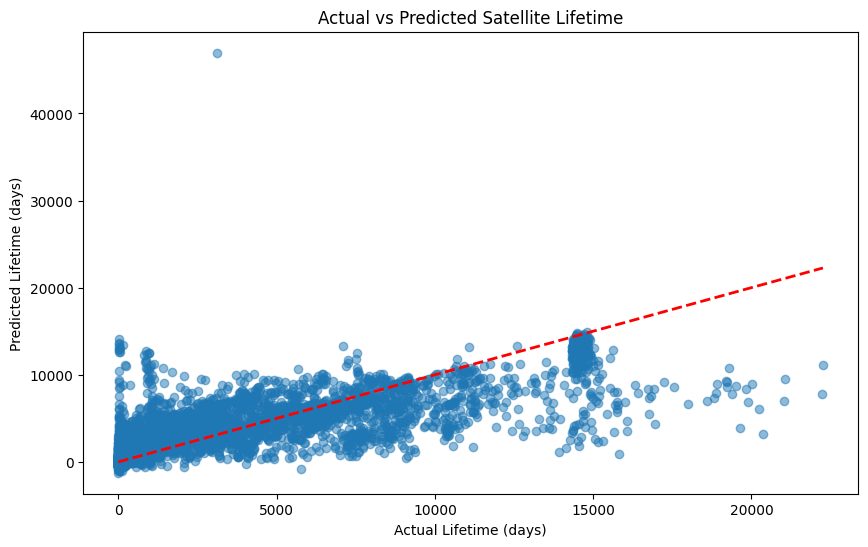

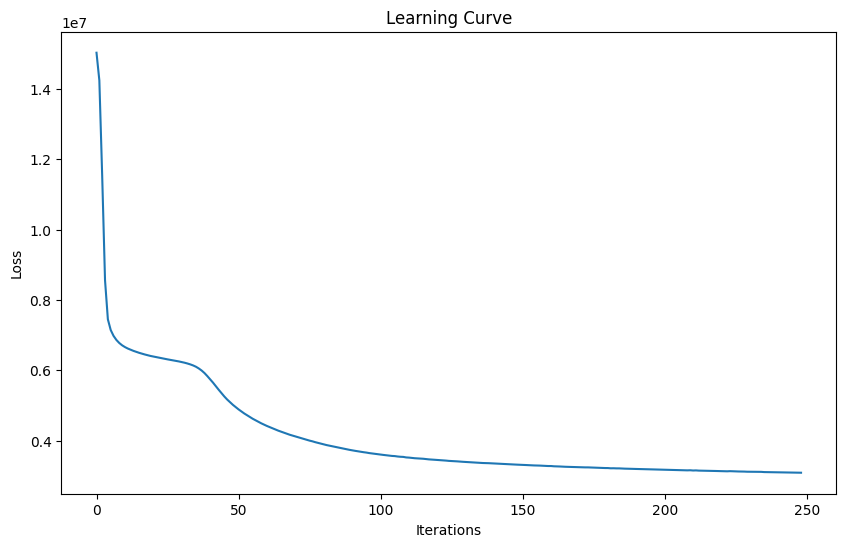

In [ ]:
plot_curves(y_pred=y_pred, y_test=y_test, mlp=mlp)

In [ ]:
results = analyze_predictions(mlp, X_test, y_test, scaler)
print_analysis(results)

Prediction Analysis:
-------------------

Negative Predictions:
Count: 824
Values: [-383.08311371377636, -166.68779472822175, -195.41850394768056, -397.5687533660651, -172.13861043232066, -117.51302253691593, -324.63565997279176, -24.858895650069794, -148.32211872837644, -116.2466937477442, -208.4338439539469, -106.09791360545454, -59.93521788878175, -140.68802582736728, -415.6376116668786, -133.12688995476452, -260.1781052046741, -180.40867794957342, -0.818495632130788, -124.11471930808672, -270.968995521541, -30.81405607393867, -211.22568262699502, -147.22377231249249, -266.7649500560696, -64.82143000235558, -71.0552859780577, -24.026646905118934, -473.42962361229996, -209.79186633926852, -275.285010093906, -471.6918825647187, -144.05736928568786, -41.960843171183896, -406.5022148153149, -1050.375346334525, -270.5601306191416, -56.24097889309594, -25.672928653982506, -316.252694462319, -138.13287709182802, -532.7235274820425, -284.8823328791147, -146.03737864695785, -82.6944209319338

## Update MLP Parameters

In [ ]:
mlp_v1 = MLPRegressor(
    hidden_layer_sizes=(200, 100, 50),  # Increased complexity
    max_iter=10000,  # Increased max iterations
    random_state=42,
    activation='relu',
    solver='adam',
    alpha=0.0005,  # Slightly increased regularization
    learning_rate='adaptive',
    learning_rate_init=0.001,  # Explicitly set initial learning rate
    early_stopping=True,
    validation_fraction=0.15,  # Increased validation fraction
    n_iter_no_change=20,  # Increased patience
    warm_start=True,
    verbose=True
)

In [ ]:
mlp_v1.fit(X_train_scaled, y_train)

Iteration 1, loss = 14538546.56971035
Validation score: -0.203365
Iteration 2, loss = 8055187.74671863
Validation score: 0.297784
Iteration 3, loss = 6776836.00564898
Validation score: 0.324292
Iteration 4, loss = 6592576.82044546
Validation score: 0.337858
Iteration 5, loss = 6478572.74035610
Validation score: 0.348199
Iteration 6, loss = 6389685.40501289
Validation score: 0.356007
Iteration 7, loss = 6323761.87259025
Validation score: 0.362522
Iteration 8, loss = 6262507.11594062
Validation score: 0.368535
Iteration 9, loss = 6194350.30831239
Validation score: 0.375848
Iteration 10, loss = 6103716.52264360
Validation score: 0.387662
Iteration 11, loss = 5966764.92196807
Validation score: 0.405621
Iteration 12, loss = 5760504.38776823
Validation score: 0.430193
Iteration 13, loss = 5487246.72786717
Validation score: 0.461924
Iteration 14, loss = 5180280.94741422
Validation score: 0.490037
Iteration 15, loss = 4901121.06934626
Validation score: 0.520407
Iteration 16, loss = 4652886.866

MLPRegressor(alpha=0.0005, early_stopping=True,
             hidden_layer_sizes=(200, 100, 50), learning_rate='adaptive',
             max_iter=10000, n_iter_no_change=20, random_state=42,
             validation_fraction=0.15, verbose=True, warm_start=True)

In [ ]:
# Make predictions
y_pred = mlp_v1.predict(X_test_scaled)

Root Mean Squared Error: 2820.062791298282
Mean Absolute Error: 1294.0934332655247
R-squared Score: 0.5876492383269382


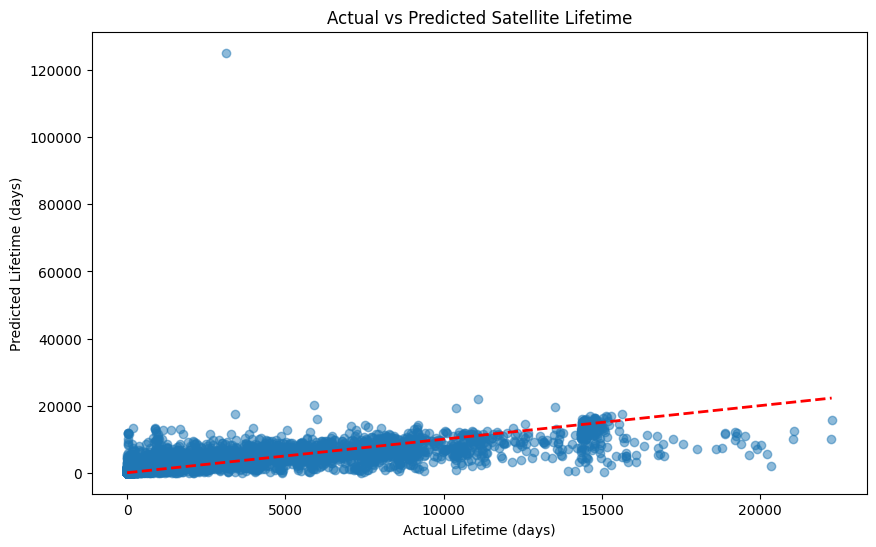

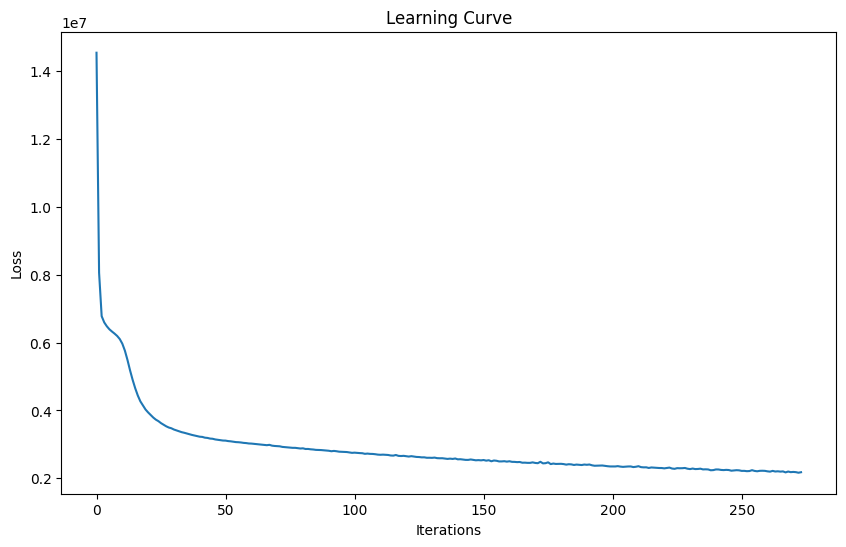

In [ ]:
plot_curves(y_pred=y_pred, y_test=y_test, mlp=mlp_v1)

## Further fine tuning

In [ ]:
from sklearn.preprocessing import RobustScaler

# Use RobustScaler to handle outliers better
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)


mlp_v2 = MLPRegressor(
    hidden_layer_sizes=(300, 200, 100),  # Increased complexity further
    max_iter=15000,  # Increased max iterations
    random_state=42,
    activation='tanh',  # Changed activation function
    solver='adam',
    alpha=0.001,  # Increased regularization
    learning_rate='adaptive',
    learning_rate_init=0.0005,  # Decreased initial learning rate
    early_stopping=True,
    validation_fraction=0.2,  # Increased validation fraction
    n_iter_no_change=30,  # Increased patience further
    warm_start=True,
    verbose=True,
    tol=0.00005  # Decreased tolerance for potentially better fine-tuning
)

# using cross-validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(mlp_v2, X_scaled, y, cv=5, scoring='r2')
print(f"Cross-validation scores: {scores}")
print(f"Mean R-squared: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

Streaming output truncated to the last 5000 lines.
Validation score: 0.222300
Iteration 741, loss = 8278500.39050150
Validation score: 0.225253
Iteration 742, loss = 8313862.29465459
Validation score: 0.220244
Iteration 743, loss = 8318264.94101607
Validation score: 0.221431
Iteration 744, loss = 8286418.47716091
Validation score: 0.224357
Iteration 745, loss = 8281086.47737149
Validation score: 0.220251
Iteration 746, loss = 8298654.92712253
Validation score: 0.224011
Iteration 747, loss = 8263131.95235414
Validation score: 0.222157
Iteration 748, loss = 8251261.68481685
Validation score: 0.226937
Iteration 749, loss = 8227188.14403732
Validation score: 0.225767
Iteration 750, loss = 8231759.64262784
Validation score: 0.227523
Iteration 751, loss = 8219788.64106168
Validation score: 0.236031
Iteration 752, loss = 8236017.88802207
Validation score: 0.226078
Iteration 753, loss = 8221733.15986092
Validation score: 0.228435
Iteration 754, loss = 8205291.66714654
Validation score: 0.22750

NameError: name 'mlp' is not defined

In [ ]:
# Then fit on the entire dataset
mlp_v2.fit(X_scaled, y)

Iteration 1, loss = 5761645.91934168
Validation score: 0.440268
Iteration 2, loss = 5694467.09278932
Validation score: 0.438747
Iteration 3, loss = 5750968.57473722
Validation score: 0.433900
Iteration 4, loss = 5759788.81228904
Validation score: 0.424377
Iteration 5, loss = 5771284.94320654
Validation score: 0.425803
Iteration 6, loss = 5742766.93603818
Validation score: 0.432402
Iteration 7, loss = 5694084.31423396
Validation score: 0.427347
Iteration 8, loss = 5722537.92388013
Validation score: 0.426707
Iteration 9, loss = 5760432.04057710
Validation score: 0.427398
Iteration 10, loss = 5741589.66801527
Validation score: 0.425807
Iteration 11, loss = 5719096.67828410
Validation score: 0.427778
Iteration 12, loss = 5655925.85385114
Validation score: 0.428025
Iteration 13, loss = 5689526.73216000
Validation score: 0.432086
Iteration 14, loss = 5627990.23803561
Validation score: 0.422531
Iteration 15, loss = 5734205.36214667
Validation score: 0.425032
Iteration 16, loss = 5670479.94617

MLPRegressor(activation='tanh', alpha=0.001, early_stopping=True,
             hidden_layer_sizes=(300, 200, 100), learning_rate='adaptive',
             learning_rate_init=0.0005, max_iter=15000, n_iter_no_change=30,
             random_state=42, tol=5e-05, validation_fraction=0.2, verbose=True,
             warm_start=True)

In [ ]:
y_pred = mlp_v2.predict(X_test_scaled)

Root Mean Squared Error: 4540.370579254919
Mean Absolute Error: 2642.7300704326776
R-squared Score: -0.06888712531272811


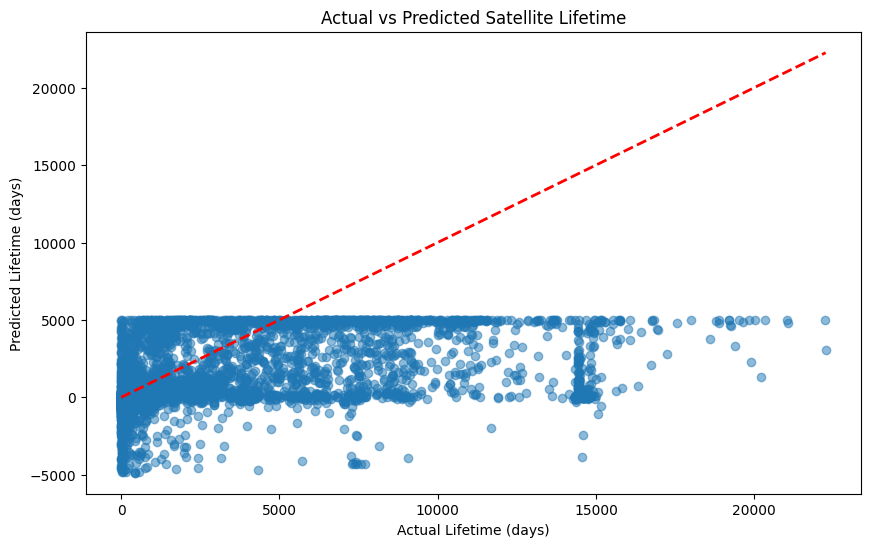

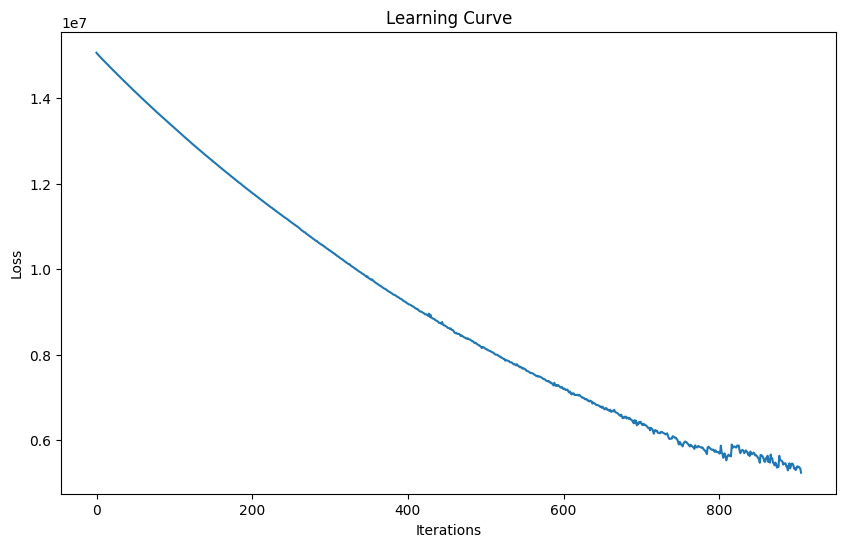

In [ ]:
plot_curves(y_pred=y_pred, y_test=y_test, mlp=mlp_v2)

In [ ]:
from sklearn.preprocessing import RobustScaler

# Use RobustScaler to handle outliers better
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)


mlp_v2 = MLPRegressor(
    hidden_layer_sizes=(300, 200, 100),  # Increased complexity further
    max_iter=15000,  # Increased max iterations
    random_state=42,
    activation='relu',  # Changed activation function
    solver='adam',
    alpha=0.001,  # Increased regularization
    learning_rate='adaptive',
    learning_rate_init=0.0005,  # Decreased initial learning rate
    early_stopping=True,
    validation_fraction=0.2,  # Increased validation fraction
    n_iter_no_change=30,  # Increased patience further
    warm_start=True,
    verbose=True,
    tol=0.00005  # Decreased tolerance for potentially better fine-tuning
)

# using cross-validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(mlp_v2, X_scaled, y, cv=5, scoring='r2')
print(f"Cross-validation scores: {scores}")
print(f"Mean R-squared: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

Iteration 1, loss = 16150067.46848374
Validation score: -0.503995
Iteration 2, loss = 15754856.77892547
Validation score: -0.459784
Iteration 3, loss = 15440628.83390706
Validation score: -0.397888
Iteration 4, loss = 15048578.96497375
Validation score: -0.322666
Iteration 5, loss = 13611729.42975814
Validation score: -0.206356
Iteration 6, loss = 12207366.13833420
Validation score: -0.058447
Iteration 7, loss = 11363465.69921545
Validation score: 0.035462
Iteration 8, loss = 10171922.85346826
Validation score: 0.070723
Iteration 9, loss = 9628932.25721737
Validation score: 0.064425
Iteration 10, loss = 9477152.06012795
Validation score: 0.097445
Iteration 11, loss = 9528776.92254084
Validation score: 0.130056
Iteration 12, loss = 9303258.59291250
Validation score: 0.132420
Iteration 13, loss = 9313729.06246892
Validation score: 0.131697
Iteration 14, loss = 9184578.40896231
Validation score: 0.133943
Iteration 15, loss = 9167214.99328388
Validation score: 0.155399
Iteration 16, loss =

## Tensorflow Implementation for finer control

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [ ]:
# Load and preprocess the data
def preprocess_data(df):
    df = df.dropna(subset=['LIFETIME_DAYS'])
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    imputer = SimpleImputer(strategy='mean')
    df[numeric_columns] = imputer.fit_transform(df[numeric_columns])
    return df

In [ ]:
data1.head()

,OBJECT_TYPE,PERIOD,INCLINATION,APOGEE,PERIGEE,RCS_SIZE,MEAN_MOTION,ECCENTRICITY,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,APOAPSIS,PERIAPSIS,LIFETIME_DAYS
3,PAYLOAD,88.48,33.15,215.0,183.0,None,16.275463,0.002474,334.6171,311.5310,48.3249,0,58402.0,0.0,0.077188,0.0,6577.283,215.419,182.876,4441.0
7,PAYLOAD,88.43,65.06,255.0,139.0,LARGE,16.283281,0.008832,163.5585,135.6760,224.6847,0,10000.0,0.0,0.026071,0.0,6575.177,255.113,138.972,692.0
8,PAYLOAD,92.81,50.25,585.0,239.0,None,15.516125,0.025453,82.4216,57.7226,303.5234,0,6070.0,0.0,0.008929,0.0,6790.158,584.856,239.191,454.0
14,PAYLOAD,762.25,46.95,42276.0,251.0,None,1.889139,0.760181,49.6823,47.2577,341.8928,0,100.0,0.0,0.000081,0.0,27641.364,42275.674,250.783,693.0
16,ROCKET BODY,718.96,47.10,40215.0,198.0,SMALL,2.002907,0.752640,284.3200,171.0000,203.9657,0,1007.0,0.0,0.000702,0.0,26584.487,40214.901,197.803,693.0


In [ ]:
data1 = preprocess_data(data1)

# Prepare features and target
X = data.drop(['LIFETIME_DAYS'], axis=1)
y = data['LIFETIME_DAYS']

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Build the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [ ]:
# Evaluate the model
def evaluate_model(model, history, X_test_scaled, y_test):
  test_results = model.evaluate(X_test_scaled, y_test, verbose=0)
  print(f"Test Mean Absolute Error: {test_results[1]:.2f}")
  print(f"Test Mean Squared Error: {test_results[2]:.2f}")

  # Make predictions
  y_pred = model.predict(X_test_scaled).flatten()

  # Calculate R-squared
  r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - np.mean(y_test))**2))
  print(f"R-squared Score: {r2:.4f}")

  # Plot actual vs predicted values
  plt.figure(figsize=(10, 6))
  plt.scatter(y_test, y_pred, alpha=0.5)
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
  plt.xlabel("Actual Lifetime (days)")
  plt.ylabel("Predicted Lifetime (days)")
  plt.title("Actual vs Predicted Satellite Lifetime")
  plt.show()

  # Plot learning curves
  plt.figure(figsize=(12, 4))
  plt.subplot(1, 2, 1)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title('Model Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(history.history['mae'], label='Training MAE')
  plt.plot(history.history['val_mae'], label='Validation MAE')
  plt.title('Model MAE')
  plt.xlabel('Epoch')
  plt.ylabel('MAE')
  plt.legend()
  plt.tight_layout()
  plt.show()

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])

In [ ]:
# Train the model
history = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=100, batch_size=32, verbose=1)

Test Mean Absolute Error: 1487.84
Test Mean Squared Error: 6296905.50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
R-squared Score: 0.6777


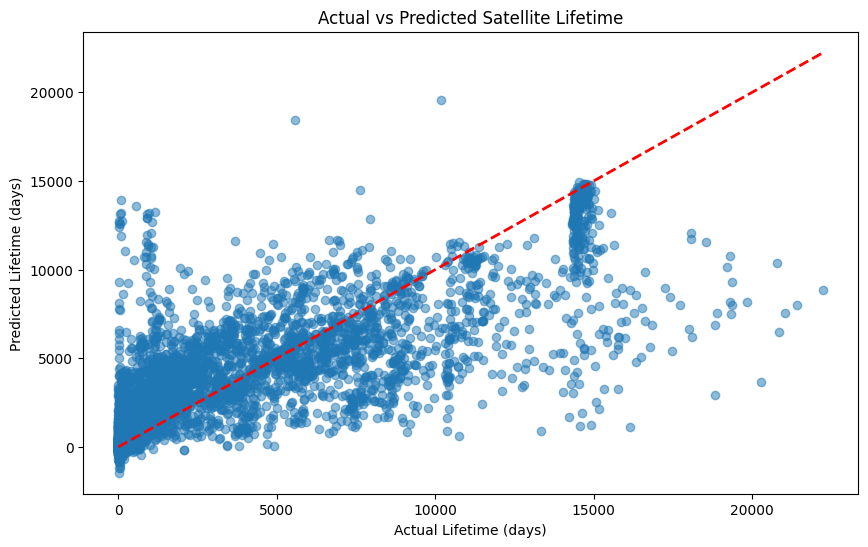

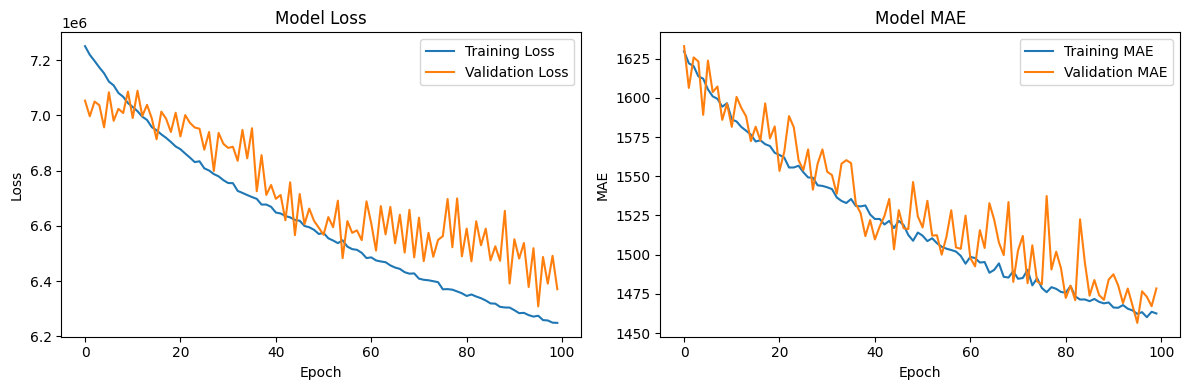

In [ ]:
evaluate_model(model, history)

In [ ]:
# Build the enhanced model
model_v1 = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='relu')
])

In [ ]:
# Compile the model
model_v1.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])

In [ ]:
# Train the model
history_v1 = model_v1.fit(X_train_scaled, y_train, validation_split=0.2, epochs=200, batch_size=32, verbose=1)

Epoch 1/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 13271908.0000 - mae: 2443.6216 - mse: 13271908.0000 - val_loss: 11854215.0000 - val_mae: 2288.3218 - val_mse: 11854215.0000
Epoch 2/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 11509071.0000 - mae: 2215.6753 - mse: 11509071.0000 - val_loss: 8845283.0000 - val_mae: 1959.9312 - val_mse: 8845283.0000
Epoch 3/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8691849.0000 - mae: 1887.3588 - mse: 8691849.0000 - val_loss: 7653962.0000 - val_mae: 1748.9668 - val_mse: 7653962.0000
Epoch 4/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7906712.0000 - mae: 1714.1316 - mse: 7906712.0000 - val_loss: 7066090.5000 - val_mae: 1629.3190 - val_mse: 7066090.5000
Epoch 5/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 7444503.0000 - mae: 1632.4834 - mse: 7444503.0000 - val_loss: 6660080.0000 - val_mae: 1549.7393 - val_mse: 6660080.0000
Epoch 6/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6849420.5000 - mae: 1534.60

In [ ]:
evaluate_model(model_v1, history_v1)

Model seems to be overfitting as expected.
Tune hyper parameters

## Hyperparameter Tuning

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.5 MB/s eta 0:00:00


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from kerastuner import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters

In [ ]:
def build_model(hp):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(hp.Int('units_1', min_value=32, max_value=256, step=32),
                                    activation='relu', input_shape=(X_train.shape[1],)))
    model.add(tf.keras.layers.Dropout(hp.Float('dropout_1', min_value=0.0, max_value=0.5, step=0.1)))
    model.add(tf.keras.layers.Dense(hp.Int('units_2', min_value=16, max_value=128, step=16),
                                    activation='relu'))
    model.add(tf.keras.layers.Dropout(hp.Float('dropout_2', min_value=0.0, max_value=0.5, step=0.1)))
    model.add(tf.keras.layers.Dense(1))

    model.compile(
        optimizer=Adam(hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')),
        loss='mse',
        metrics=['mae', 'mse']
    )
    return model

In [ ]:
# Set up the hyperparameter tuning
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=3,
    directory='hyperparameter_tuning',
    project_name='debris_lifetime_prediction'
)

In [ ]:
# Perform the hyperparameter search
tuner.search(X_train_scaled, y_train, epochs=100, validation_split=0.2, callbacks=[
    EarlyStopping(patience=10, restore_best_weights=True)
])

Trial 5 Complete [00h 10m 09s]
val_loss: 11118890.0

Best val_loss So Far: 6142640.0
Total elapsed time: 00h 51m 36s


In [ ]:
# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

In [ ]:
# Print the best hyperparameters
print("\nBest Hyperparameters:")
print(f"units_1: {best_hps.get('units_1')}")
print(f"dropout_1: {best_hps.get('dropout_1')}")
print(f"units_2: {best_hps.get('units_2')}")
print(f"dropout_2: {best_hps.get('dropout_2')}")
print(f"learning_rate: {best_hps.get('learning_rate')}")


Best Hyperparameters:
units_1: 96
dropout_1: 0.1
units_2: 48
dropout_2: 0.0
learning_rate: 0.0017177623555536738


In [ ]:
# Build the final model with the best hyperparameters
model_tuned = tuner.hypermodel.build(best_hps)

In [ ]:
# Define callbacks
callbacks = [
    EarlyStopping(patience=20, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)
]

In [ ]:
# Train the final model
history_tuned = model_tuned.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 25549076.0000 - mae: 2920.9407 - mse: 25549076.0000 - val_loss: 13614215.0000 - val_mae: 2483.3416 - val_mse: 13614215.0000 - learning_rate: 0.0017
Epoch 2/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13807934.0000 - mae: 2471.0452 - mse: 13807934.0000 - val_loss: 13339638.0000 - val_mae: 2519.7280 - val_mse: 13339638.0000 - learning_rate: 0.0017
Epoch 3/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 13469008.0000 - mae: 2462.9275 - mse: 13469008.0000 - val_loss: 13143839.0000 - val_mae: 2473.9211 - val_mse: 13143839.0000 - learning_rate: 0.0017
Epoch 4/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13251267.0000 - mae: 2437.2239 - mse: 13251267.0000 - val_loss: 13074569.0000 - val_mae: 2469.3281 - val_mse: 13074569.0000 - learning_rate: 0.0017
Epoch 5/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 12970899.0000 - mae: 2413.3599 - mse: 12970899.0000 - val_loss: 12948604.0000 - val_mae: 2433.0388 - va

Test Mean Absolute Error: 1454.66
Test Mean Squared Error: 6219538.50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
R-squared Score: 0.6816


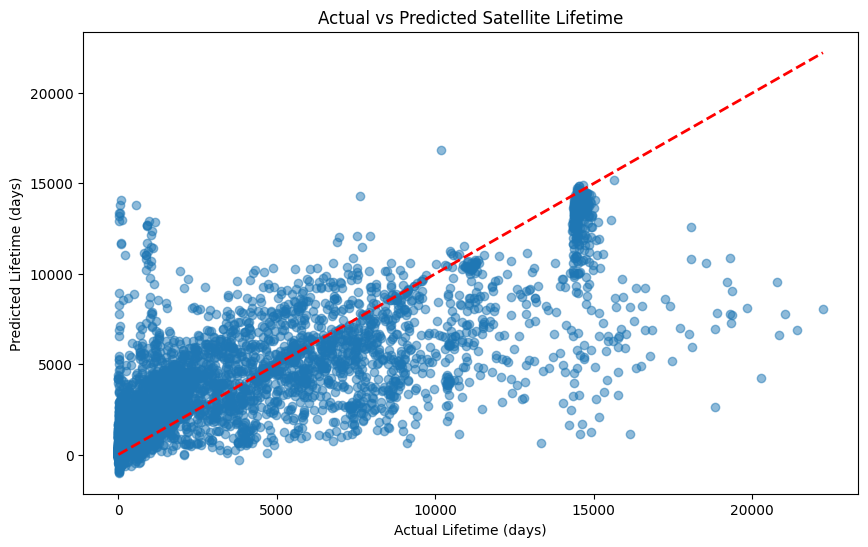

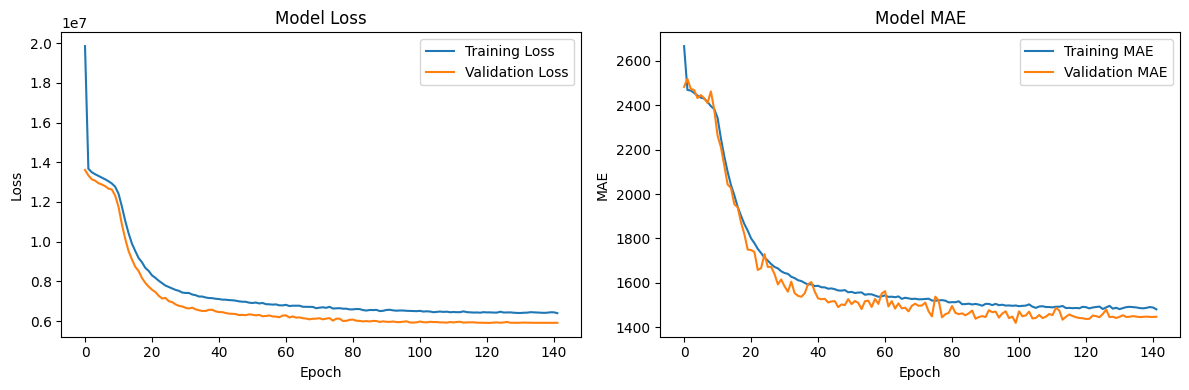

In [ ]:
evaluate_model(model_tuned, history_tuned)